# **===========================================================================================================================================================** #
# **Applied Data Science with Python: Unit 2 End Project** #
# **===========================================================================================================================================================** #

## <u>**Notebook Setup**</u> ##

In [456]:
# Import Libraries
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import t
from scipy.stats import boxcox, yeojohnson, shapiro
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import seaborn as sns
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.metrics import mean_absolute_error
from sklearn.neighbors import LocalOutlierFactor
from sklearn.ensemble import IsolationForest

from sklearn.preprocessing import (
    KBinsDiscretizer,
    PowerTransformer,
    QuantileTransformer,
    MinMaxScaler,
    StandardScaler,
    OrdinalEncoder,
    OneHotEncoder,
    LabelEncoder,
    PolynomialFeatures
)
import platform
import sys

# How to tell python version
#print (sys.version_info)
#print (platform.python_version())

# How to pip install from Terminal window:
# python -m pip install seaborn

# Put this at the top of your notebook
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', 1000)  # Set a large number
pd.set_option('display.max_colwidth', None)

# Set random seed for reproducibility
np.random.seed(315)


#### **Utility Function Definitons** ####

In [457]:
def OrdinalEncodeCategoricalFeature(df_target, feature_name, categories):
    
    # Apply ordinal encoding
    encoder = OrdinalEncoder(categories=categories)

    encoded_feature_name = f'{feature_name}_encoded'
    df_target[encoded_feature_name] = encoder.fit_transform(df_target[[feature_name]])

    # Display mapping
    print('Ordinal encoding mapping:')
    df_target[[feature_name, encoded_feature_name]].drop_duplicates().sort_values(encoded_feature_name)  

    df_target = df_target.drop(feature_name, axis=1)    
    
    return df_target  

def OneHotEncodeCategoricalFeature(df_target, feature_name):

    encoder = OneHotEncoder(sparse_output=False, drop='first')

    #
    # Encode Feature
    #
    onehot_array = encoder.fit_transform(df_target[[feature_name]])

    # Create dataframe with proper column names
    df_onehot = pd.DataFrame(
        onehot_array,
        columns=encoder.get_feature_names_out([feature_name]),
        index=df_target.index
    )

    # Join back to original and drop original column
    df_target = pd.concat([df_target, df_onehot], axis=1)
    df_target = df_target.drop(feature_name, axis=1)    

    return df_target

def EncodeDateFeatures(df_target):
    # Split Date into Day, Month, Year
    df_target['Month'] = df_target['Date'].dt.month
    df_target['DayOfWeek'] = df_target['Date'].dt.dayofweek    # 0=Monday, 6=Sunday
    #df_target['Day'] = df_target['Date'].dt.day  - Day of month doesn't make sense as we already of month start/end
    df_target['WeekOfYear'] = df_target['Date'].dt.isocalendar().week
    #df_target['DayOfYear'] = df_target['Date'].dt.dayofyear
    df_target['IsMonthStart'] = df_target['Date'].dt.is_month_start.astype(int)
    df_target['IsMonthEnd'] = df_target['Date'].dt.is_month_end.astype(int)
    # df_target['IsQuarterStart'] = df_target['Date'].dt.is_quarter_start.astype(int)  - Not usefl for 1 quarters worth of data
    # df_target['IsQuarterEnd'] = df_target['Date'].dt.is_quarter_end.astype(int)
    df_target['Weekend'] = (df_target['Date'].dt.dayofweek >= 5).astype(int)
    #df_target['Year'] = df_target['Date'].dt.year  - Doesn't make sense since we've only have data for 1 quarter in 1 year

    # Fix Year - Negatively Skewed Coeffs
    # Fix 1: Normalize Year
    #df_target['Year'] = df_target['Year'] - df_target['Year'].min()
    #df_target = df_target.drop('Date', axis=1)

    df_target = df_target.drop('Date', axis=1)   

    # print("Year min:", df_target['Year'].min())
    # print("Year max:", df_target['Year'].max())
    # 
    return df_target    

def EncodeCategoricalFeatures(df_target):

    df_target = OneHotEncodeCategoricalFeature(df_target, 'State')
    df_target = OneHotEncodeCategoricalFeature(df_target, 'Group')
    df_target = OrdinalEncodeCategoricalFeature(df_target, 'TimeOfDay', [['Morning', 'Afternoon', 'Evening']])
    df_target = EncodeDateFeatures(df_target)
    
    return df_target

## <u>**1. Data Import and Initial Exploratory Data Analysis**</u> ##

In [458]:
# Import data into DataFrame
# Renamed CSV file is assumed to live in same folder as my notebook
df_ausapparalsales = pd.read_csv("AusApparalSales4thQrt2020.csv")

# Make a copy of the dataframe to contain the modifications completed in this workbook
# Keep the original unmodified data for reference purposes.
df_ausapparalsales_new = df_ausapparalsales.copy(deep=True)

# Create a globel name for the data set
data_set_name = 'Australian Apparel Sales'

# Let's look at what we just imported and get some more info
# I like to delineate output to make it more readable

def PrintDataFrameStatus(df_target):
    # Print Stats
    print("***********************************")
    print("Description Stats")
    print("***********************************")
    print()
    print(df_target.describe(include='all').T)
    print()

    # Print df Column Info
    print("***********************************")
    print("Basic Info of imported data set")
    print("***********************************")
    print()
    df_target.info()
    print()
    print()

    print(f'df_floridabikerentals Shape:{df_target.shape}')
    print()

    print('Do we have any features with null values?:')
    print(df_target.isnull().any().any())
    print()

    print('Feature Columns with that have null values:')
    print(df_target.isnull().sum()[df_target.isnull().sum() > 0])
    print()

    print('Do we have any features with nan values?:')
    print(df_target.isna().any().any())

    print("***********************************")
    print("First 20 rows of Data")
    print("***********************************")
    print()
    print(df_target.head(20))
    print()

    print("***********************************")
    print("First 20 rows of Random Sample Data")
    print("***********************************")
    print()
    print(df_target.sample(20))
    print

PrintDataFrameStatus(df_ausapparalsales)

***********************************
Description Stats
***********************************

        count unique       top  freq          mean           std     min      25%      50%      75%       max
Date     7560     90  1-Oct-20    84           NaN           NaN     NaN      NaN      NaN      NaN       NaN
Time     7560      3   Morning  2520           NaN           NaN     NaN      NaN      NaN      NaN       NaN
State    7560      7        WA  1080           NaN           NaN     NaN      NaN      NaN      NaN       NaN
Group    7560      4      Kids  1890           NaN           NaN     NaN      NaN      NaN      NaN       NaN
Unit   7560.0    NaN       NaN   NaN     18.005423     12.901403     2.0      8.0     14.0     26.0      65.0
Sales  7560.0    NaN       NaN   NaN  45013.558201  32253.506944  5000.0  20000.0  35000.0  65000.0  162500.0

***********************************
Basic Info of imported data set
***********************************

<class 'pandas.core.frame.DataFra

### **Results of Initial Investigation** ###
    - We have 7,560 rows of data
    - The dataset contains 5 columns (features)
    - Initial testing reveals that we don't have any missing data/empty values
    - State - This is Australia, verify that the values in this column are indeed valid Australian states (should be encoded)
    - Group - Identify the "valid" groups and make sure we don't have any anamolies (should be encoded)

    - The column types look correct (as what we'd expect) except for Date and Time
      We should investigate translating these into Date and Time:
        - Date (object) => Date type
          Date can then be further broken up into day, month, year day of week,
        - Time (object) => It's not an exact time, it's a "Time of Day".
          Keep it. It will make sense to encode this. We should verify that this column contains expected values.
    - For more of potential trend revealing views we probably want to investigate binning
      these values into:
        - Date => If this contained data for a full year, then it would make sense to create category for seasons (Fall, Winter, Spring, Summer)
                  But since this for the 4th quarter, then it we know it summer (by default, since its Australia)
                  (This can always be added in if we merge into multi season/year data set)
                  Are there any holidays that occur during this time span in Austrlia - we know Christmas, but are there others?
                  Since we are only dealing with 1 quarter in in 1 year, we can drop the year as it won't have any bearing in our models.
                  (This can always be added back in if we merge into multi year data set)
        - Time => TimeOfDay (Morning, Afternoon, Evening, Night)


#### **Potential Data Issues from Imported Data** ####
    1. The following columns (features) have missing data:
        There are no features with missing/null/<nan> data.
    
##### **Validate Data Features** #####
    Test each in data column to ensure it's context and validity

In [459]:
print('==========================================================================')

#
# Date - are dates all valid?
#
invalid_dates = df_ausapparalsales[pd.to_datetime(df_ausapparalsales['Date'], errors='coerce').isna()]
if len(invalid_dates) > 0:
    print('Invalid Dates were found.')
    print(invalid_dates)
else:
    print('No invalid Dates were found.')
print()

#
# Time - Unique 'Times of Day'? Are they valid?
#
n_times = df_ausapparalsales['Time'].nunique()
times = df_ausapparalsales['Time'].unique()
print(f'There are: {n_times} unique times (times of day)')
print(times)
print()

#
# State - Are these all valid Australian States?
#
n_states = df_ausapparalsales['State'].nunique()
states = df_ausapparalsales['State'].unique()
print(f'There are: {n_states} unique states (Austrlian States)')
print(states)
print()

#
# Group - Do these all sound like valid age groups?
#
n_groups = df_ausapparalsales['Group'].nunique()
groups = df_ausapparalsales['Group'].unique()
print(f'There are: {n_groups} unique groups (Age Groups)')
print(groups)
print()

# Following tests are redundant, but explicit. We already can see this through Descriptive Stats
#
# Unit - Are all these number fields?
#
invalid_units = df_ausapparalsales[pd.to_numeric(df_ausapparalsales['Unit'], errors='coerce').isna()]
if len(invalid_units) > 0:
    print('Invalid Units were found.')
    print(invalid_units)
else:
    print('No invalid Units were found.')
print()

# Check relationship between Unit and Sales
# 1 unit == $2500 in sales
# Verify that this is consistent
mismatches = df_ausapparalsales[df_ausapparalsales['Sales'] != df_ausapparalsales['Unit'] * 2500]
if len(mismatches) > 0:
    print('Mismatches were found in relationship between Unit and Sales')
    print(mismatches)
else:
    print('No mismatches were found in relationship between Unit and Sales')
print()

#
# Sales - Are all these number fields?
#
invalid_sales = df_ausapparalsales[pd.to_numeric(df_ausapparalsales['Sales'], errors='coerce').isna()]
if len(invalid_sales) > 0:
    print('Invalid Sales were found.')
    print(invalid_sales)
else:
    print('No invalid Sales were found.')
print()

print('==========================================================================')
print()

No invalid Dates were found.

There are: 3 unique times (times of day)
[' Morning' ' Afternoon' ' Evening']

There are: 7 unique states (Austrlian States)
[' WA' ' NT' ' SA' ' VIC' ' QLD' ' NSW' ' TAS']

There are: 4 unique groups (Age Groups)
[' Kids' ' Men' ' Women' ' Seniors']

No invalid Units were found.

No mismatches were found in relationship between Unit and Sales

No invalid Sales were found.




C:\Users\jxbma\AppData\Local\Temp\ipykernel_36192\1413544390.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  invalid_dates = df_ausapparalsales[pd.to_datetime(df_ausapparalsales['Date'], errors='coerce').isna()]


##### **Data Validation Observations** #####
    Date - feature looks clean and good as valid dates.

    Unit, Sales - look clean and good as valid numeric fields.
    Unit  - Not exactly sure what this represents.
            Is this some sort of category?
            Or.., is it units sold?
            Best guess is that this is units sold.
            Based on the relationship between Sales and Units
                - 1 unit = $2500 in sales
                    - 8 units = $20000
                    - 4 units = $10000
                    - 2 units - $5000
            We'll need to check on consistency of this mathematical relationship further on.

    Group - 'Groups' looks clean (no missing values).
            There are 4 Groups.
            Initially I thought these were age groups, but upon further examination, these are groups.
            Specific labels for Groups look valid.
            Should be encoded - OneHotEncoded
            If we wanted to look at "AgeGroups", it might make sense to combine Men/Women so
            we have the following "AgeGroups" - [Kids, Adults, Seniors].
            This will depend on when we're looking at building models and potentially adding features.
            Leave this as a TBDetermined later task.

    Time - 'Times of Day' looks clean (no missing values).
           There are 4 Age Broups
           Specific labels for Age Groups look valid.
           Feature should be renamed to 'TimeOfDay' - more descriptive

    State - looks clean (no missing values).
            The data set contains 7 states.
            Australia has 8 states.
            They are: 'NSW', 'VIC', 'QLD', 'WA', 'SA', 'TAS', 'NT', 'ACT'
            This data set has no data for 'ACT' [Australian Capital Territory]
            Specific labels for States look valid.

    State, Time and Group
##### **Initial Data Corrections** #####

In [460]:
#
# Column Renaming
#
df_ausapparalsales_new.rename(columns={'Time': 'TimeOfDay'}, inplace=True)

#
# Make sure string columns are trimmed
#
for col in df_ausapparalsales_new.select_dtypes(include='object').columns:
    df_ausapparalsales_new[col] = df_ausapparalsales_new[col].str.strip()

#
# Convert Date Field from string to date
#
df_ausapparalsales_new['Date'] = pd.to_datetime(df_ausapparalsales_new['Date'])
#PrintDataFrameStatus(df_ausapparalsales_new)

C:\Users\jxbma\AppData\Local\Temp\ipykernel_36192\437529528.py:15: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_ausapparalsales_new['Date'] = pd.to_datetime(df_ausapparalsales_new['Date'])


#### <b>Initial Histograms of Raw Numeric Features</b> ####

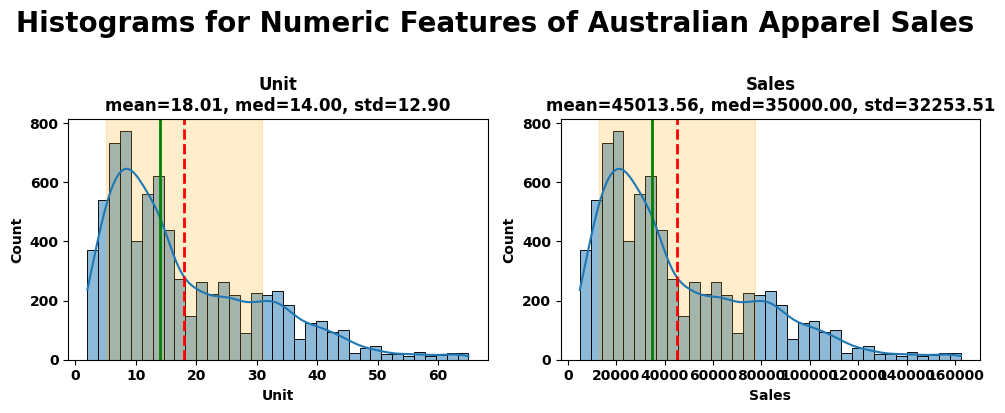

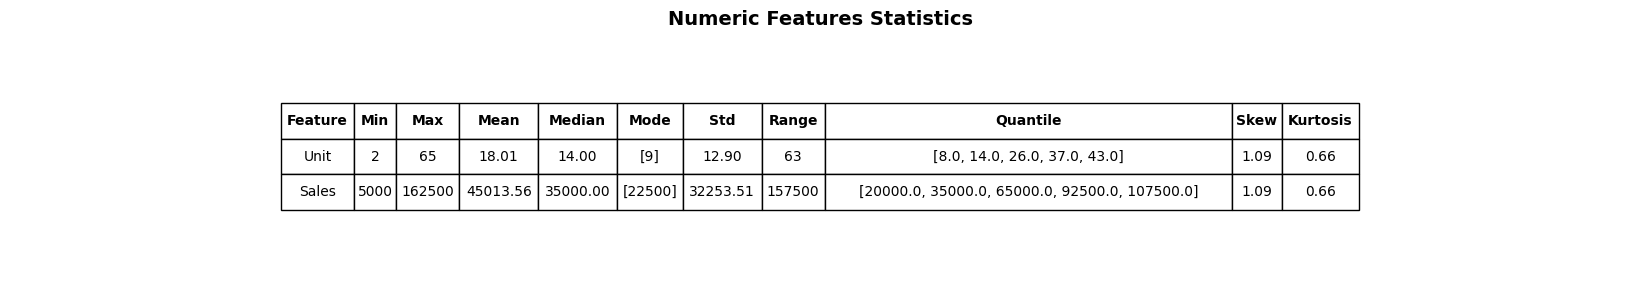

In [461]:
def DisplayTable(df_target, table_title=None):
    
    n_rows, n_cols = df_target.shape
    
    fig, ax = plt.subplots(figsize=(n_cols * 1.5, (n_rows + 1) * 1.0))  # increased height multiplier
    ax.axis('off')

    # Format floats to 2 decimal places
    # I need help on this one for dynamic 
    cell_text = [[f'{val:.2f}' if isinstance(val, float) else str(val) for val in row] 
                 for row in df_target.values]

    table = ax.table(
        cellText=cell_text,
        colLabels=df_target.columns,
        #rowLabels=df_target.index,
        cellLoc='center',
        loc='center'
    )

    # Make column headers bold
    for col in range(n_cols):
        table[(0, col)].set_text_props(fontweight='bold')

    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.auto_set_column_width(col=list(range(n_cols)))
    table.scale(1.2, 2.0)  # second param controls row height

    if table_title is not None:
        plt.title(table_title, fontweight='bold', fontsize=14)
    plt.tight_layout()
    plt.show()

def DisplayNumericFeatureHistgorams(df_target, feature_columns = None, target_label=None, plot_title=None, display_statistics=True):

    cols_to_plot = []
    statistics = []
    
    if feature_columns is None:
        cols_to_plot = df_target.select_dtypes(include=['number']).columns
    else:
        cols_to_plot = feature_columns

    if target_label is not None:
        cols_to_plot = cols_to_plot.drop(target_label).tolist()
    
    number_of_cols = len(cols_to_plot)

    ncols = min(number_of_cols, 3)  # max 3 per row, but no more than n
    nrows = (number_of_cols + ncols - 1) // ncols

    # I need a 3 column plot
    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
    axes = axes.flatten()

    # Iterate over each numeric column and plot a historbram
    for i, col in enumerate(cols_to_plot):

        sns.histplot(data=df_target, x=col, ax=axes[i], kde=True)

        axes[i].set_xlabel(col, fontweight='bold')
        axes[i].set_ylabel('Count', fontweight='bold')
        data = df_target[col]

        if display_statistics == True:

            min_val = data.min()
            max_val = data.max()
            range_val = data.max() - data.min()
            mean_val = data.mean()
            median_val = data.median()
            mode_val = data.mode().tolist()
            std_val = data.std()
            quantile_val = data.quantile([0.25, 0.5, 0.75, 0.90, 0.95]).tolist()
            skew_val = data.skew()
            kurtosis_val = data.kurtosis()

            stats = {
                'Feature': col,
                'Min': min_val,
                'Max': max_val,
                'Mean': mean_val,
                'Median': median_val,
                'Mode': mode_val,
                'Std': std_val,
                'Range': range_val,
                'Quantile': quantile_val,
                'Skew': skew_val,
                'Kurtosis': kurtosis_val
            }            

            statistics.append(stats)

            # print(f'Min Value: {min_val:.3f}')
            # print(f'Max Value: {max_val:.3f}')
            # print(f'Mean Value: {mean_val:.3f}')
            # print(f'Median Value: {median_val:.3f}')
            # print(f'Mode Value: {mode_val}')
            # print(f'Standard Deviation: {std_val:.3f}')
            # print(f'Range Value = {range_val:.3f}')
            # print(f'Quantile Value = {quantile_val}')
            # print(f'Skew Value: {skew_val:.3f}')
            # print(f'Kurtosis Value: {kurtosis_val:.3f}')            

            axes[i].set_title(f'{col}\nmean={mean_val:.2f}, med={median_val:.2f}, std={data.std():.2f}', fontweight='bold')

            # Vertical lines for mean and median, shaded std
            axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
            axes[i].axvline(median_val, color='green', linestyle='-', linewidth=2, label=f'Median: {median_val:.2f}')            
            axes[i].axvspan(mean_val - std_val, mean_val + std_val, alpha=0.2, color='orange', label=f'±1 Std')

        else:
            axes[i].set_title(f'{col}', fontweight='bold')
        
        # Tick labels in bold
        axes[i].tick_params(axis='both', labelsize=10)
        for label in axes[i].get_xticklabels() + axes[i].get_yticklabels():
            label.set_fontweight('bold')

    # Hide the blank/empty graphs
    for i in range(number_of_cols, len(axes)):
        fig.delaxes(axes[i])

    # Make plots more readable and add space
    title = None
    if plot_title is not None:
        title = plot_title
    else:
        title = f'Histograms for Numeric Features of {data_set_name}'

    plt.suptitle(f'Histograms for Numeric Features of {data_set_name}', y=1.02, fontsize=20, fontweight='bold')
    plt.subplots_adjust(top=0.92)  

    plt.tight_layout(h_pad=5)
    plt.show()  

    print()
    print()

    if display_statistics == True:
        df_statistics = pd.DataFrame(statistics)
        DisplayTable(df_statistics, 'Numeric Features Statistics')
    
#
#
#
DisplayNumericFeatureHistgorams(df_ausapparalsales_new) 

   


#### <b>Initial Observations Raw Numeric Feature Histograms</b> ####
    
    Unit           - Right Skewed Distribution, there does not appear to be any outliers
                   - Average => 18.01
                     On average, 18 Units are being sold
                   - Median => 14.00
                   - Standard Deviation is 12.90
                     Most Units are in the 6 to 30 Unit Range
                     
    Sales          - Right Skewed Distribution, there does not appear to be any outliers
                   - Average => $45,013.56
                     On average, there are $45,013.56 of sales
                   - Median => $35,000.00
                   - Standard Deviation is $32,253.51
                     Most Sales are in the $15,000.00 to $75,000.00 range

    
#### <b>Initial Bar Count plots of Raw Categoric (string) Features</b> ####    

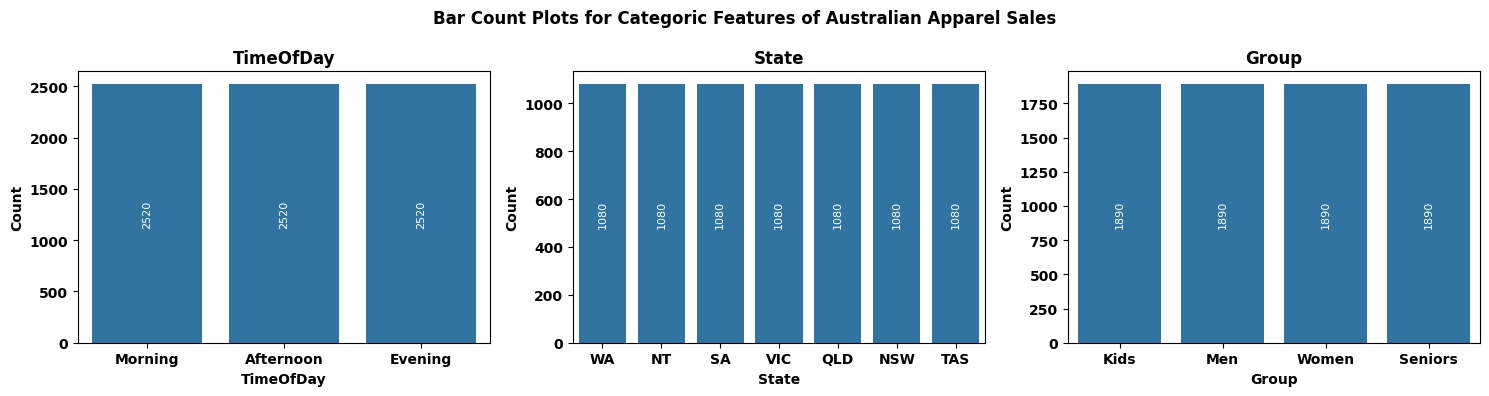

In [462]:
def DisplayBarCountPlotsOfCategoricFeatures(df_target, feature_columns = None, target_label=None, display_bar_labels=True):

    cols_to_plot = []
    if feature_columns is None:
        cols_to_plot = df_target.select_dtypes(include=['object']).columns
    else:
        cols_to_plot = feature_columns

    if target_label is not None:
        cols_to_plot = cols_to_plot.drop(target_label).tolist()
    
    number_of_cols = len(cols_to_plot)

    ncols = min(number_of_cols, 3)  # max 3 per row, but no more than n
    nrows = (number_of_cols + ncols - 1) // ncols

    # I need a 3 column plot
    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
    axes = axes.flatten()
    # Iterate over each numeric column and plot a historbram
    for i, col in enumerate(cols_to_plot):
        
        sns.countplot(data=df_target, x=col, ax=axes[i])

        axes[i].set_title(col, fontweight='bold')
        axes[i].set_xlabel(col, fontweight='bold')
        axes[i].set_ylabel('Count', fontweight='bold')

        if display_bar_labels == True:
            # Add count labels on bars
            axes[i].bar_label(axes[i].containers[0], label_type='center', fontsize=8, rotation=90, fmt='%d', color='white')

        # Tick labels in bold
        axes[i].tick_params(axis='both', labelsize=10)
        for label in axes[i].get_xticklabels() + axes[i].get_yticklabels():
            label.set_fontweight('bold')            

    # Hide the blank/empty graphs
    for i in range(number_of_cols, len(axes)):
        fig.delaxes(axes[i])

    # Make plots more readable and add space
    plt.suptitle(f'Bar Count Plots for Categoric Features of {data_set_name}', fontweight='bold')
    plt.subplots_adjust(top=0.92)  
    
    plt.tight_layout(h_pad=5)
    plt.show()  
    print()
    print()

DisplayBarCountPlotsOfCategoricFeatures(df_ausapparalsales_new)    


#### **Initial Observations Raw Categoric Bar Counts** ####
    
    TimeOfDay             - Data is evenly distributed across all TimesOfDays
                            2520 for each TimesOfDay
    State                 - Data is evenly distributed across all States
                            1080 for each State
    Group                 - Data is evenly distributed across all Groups
                            1890 for each Group

    All of the categoric feature values have even distributions.
    The data is clearly manufactures as this is not a realistic condition.

#### <b>Box Plots of Numeric Features</b> ####


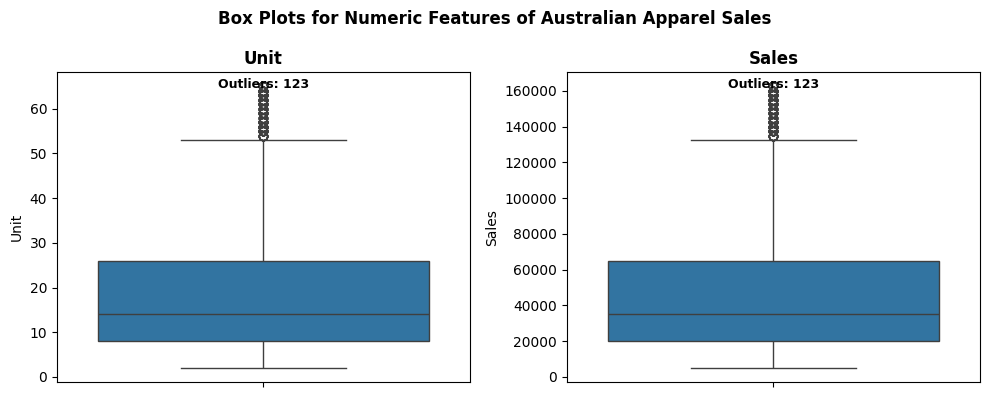

In [463]:
def PlotBoxPlotsToViewDistributions(df_target, feature_columns = None, target_label=None, plot_title=None):

    cols_to_plot = []
    if feature_columns is None:
        cols_to_plot = df_target.select_dtypes(include=['number']).columns
    else:
        cols_to_plot = feature_columns

    if target_label is not None:
        cols_to_plot = cols_to_plot.drop(target_label).tolist()
    
    number_of_cols = len(cols_to_plot)

    ncols = min(number_of_cols, 3)  # max 3 per row, but no more than n
    nrows = (number_of_cols + ncols - 1) // ncols

    # I need a 3X4 plot to display 10 histograms
    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
    axes = axes.flatten()

    #Iterate over each numeric column and plot a historgram
    for i, col in enumerate(cols_to_plot):

        sns.boxplot(data=df_target, y=col, ax=axes[i])    
        axes[i].set_title(col, fontweight='bold')

        # Optional: Add count of outliers
        Q1 = df_target[col].quantile(0.25)
        Q3 = df_target[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        outlier_count = len(df_target[(df_target[col] < lower) | 
                                            (df_target[col] > upper)])
        axes[i].text(0.5, 0.95, f'Outliers: {outlier_count}', 
                    transform=axes[i].transAxes, ha='center', fontsize=9, fontweight='bold')
        
    # Make plots more readable and add space
    title = None
    if plot_title is not None:
        title = plot_title
    else:
        title = f'Box Plots for Numeric Features of {data_set_name}'

    # Hide the blank/empty graphs
    for i in range(number_of_cols, len(axes)):
        fig.delaxes(axes[i])        

    plt.suptitle(title, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.90])  # Leave space at top
    #plt.subplots_adjust(top=0.92)        

    # Make plots more readable and add space
    plt.tight_layout(h_pad=5)
    plt.show() 

    print()
    print()

def PlotsToViewRelationships(df_target, relationships_to_plot, plot_title=None, plot_type='BoxPlot', display_crosstab=False):

    number_of_cols = len(relationships_to_plot)
    ncols = min(number_of_cols, 3)  # max 3 per row, but no more than n
    nrows = (number_of_cols + ncols - 1) // ncols

    pivot_tables_to_display = []

    # I need a 3X4 plot to display 10 histograms
    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
    axes = axes.flatten()

    if plot_type == 'BoxPlot':
        
        #Iterate over each numeric column and plot a historgram
        for i, relationship in enumerate(relationships_to_plot):

            sns.boxplot(data=df_target, 
                        y=relationship['YValue'], 
                        x=relationship['XValue'],
                        ax=axes[i])    
            
            axes[i].set_title(relationship['Title'], fontweight='bold')

            # Optional: Add count of outliers
            Q1 = df_target[relationship['YValue']].quantile(0.25)
            Q3 = df_target[relationship['YValue']].quantile(0.75)
            IQR = Q3 - Q1
            lower = Q1 - 1.5 * IQR
            upper = Q3 + 1.5 * IQR
            outlier_count = len(df_target[(df_target[relationship['YValue']] < lower) | 
                                                (df_target[relationship['YValue']] > upper)])
            axes[i].text(0.5, 0.95, f'Outliers: {outlier_count}', 
                        transform=axes[i].transAxes, ha='center', fontsize=9, fontweight='bold')
    
    elif plot_type == 'CountPlot':
        
         #Iterate over each numeric column and plot a historgram
        for i, relationship in enumerate(relationships_to_plot):

            sns.countplot(data=df_target, 
                        x=relationship['XValue'],
                        hue=relationship['YValue'],                         
                        ax=axes[i])    
            
            axes[i].set_title(relationship['Title'], fontweight='bold')

    elif plot_type == 'HeatMap':

         #Iterate over each numeric column and plot a historgram
        for i, relationship in enumerate(relationships_to_plot):

            pivot = pd.crosstab(df_target[relationship['YValue']], df_target[relationship['XValue']])

            sns.heatmap(pivot, 
                        annot=True, 
                        fmt='d',
                        cmap='YlGnBu',
                        ax=axes[i])
            
            axes[i].set_title(relationship['Title'], fontweight='bold')

            if display_crosstab == True:
                pivot_tables_to_display.append({'pivot': pivot, 'title': f"{relationship['Title']} CrossTab"})

    else:
        print('Invalid Plot Type!!!')
        return
    
    # Make plots more readable and add space
    title = None
    if plot_title is not None:
        title = plot_title
    else:
        title = f'Box Plots for Feature Relationships of {data_set_name}'

    # Hide the blank/empty graphs
    for i in range(number_of_cols, len(axes)):
        fig.delaxes(axes[i])        

    plt.suptitle(title, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.90])  # Leave space at top
    #plt.subplots_adjust(top=0.92)        

    # Make plots more readable and add space
    plt.tight_layout(h_pad=5)
    plt.show() 

    print()
    print()

    if display_crosstab == True and pivot_tables_to_display is not None:

        for table in pivot_tables_to_display:
            DisplayTable(table['pivot'], table_title=f"{table['title']} CrossTab")
            

PlotBoxPlotsToViewDistributions(df_ausapparalsales_new)


#### <b>Box Plots of Sales Relative to Features</b> ####

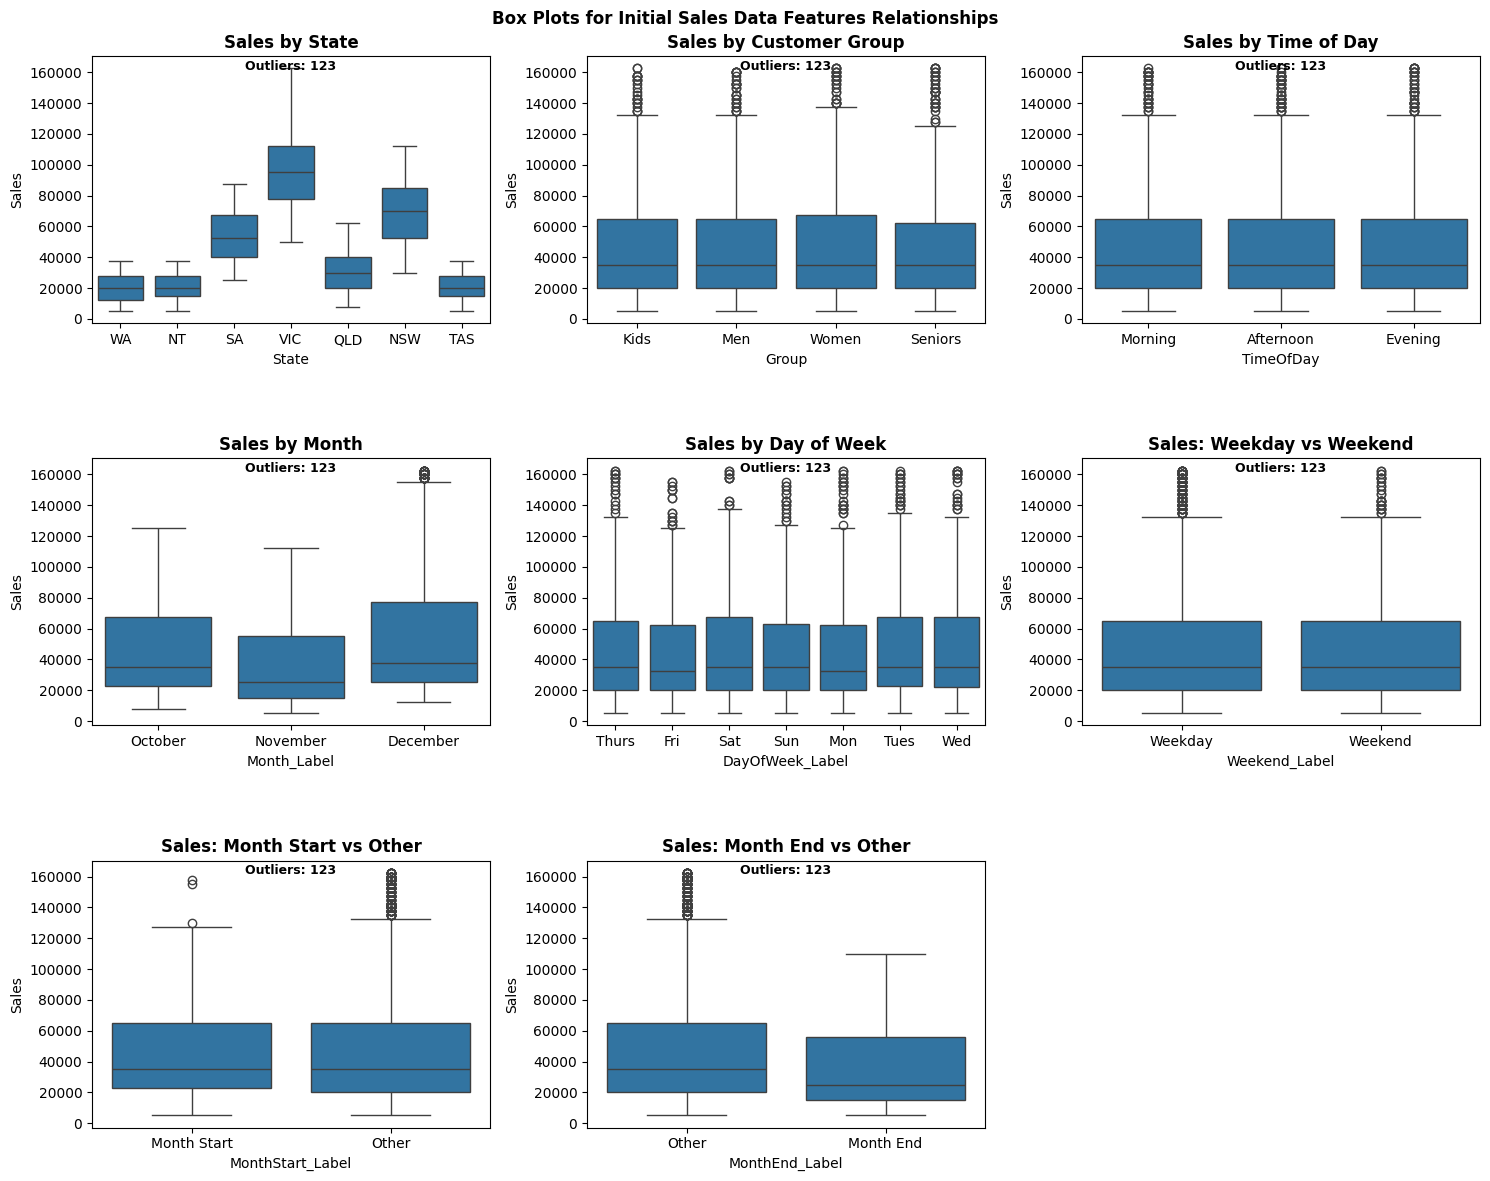

In [464]:
#
# Relational Box Plots for Sales
#

relationships_to_plot = [
    # Original categorical features
    {'XValue': 'State', 'YValue': 'Sales', 'Title': 'Sales by State'},
    {'XValue': 'Group', 'YValue': 'Sales', 'Title': 'Sales by Customer Group'},
    {'XValue': 'TimeOfDay', 'YValue': 'Sales', 'Title': 'Sales by Time of Day'},
    
    # Time-based features
    {'XValue': 'Month_Label', 'YValue': 'Sales', 'Title': 'Sales by Month'},
    {'XValue': 'DayOfWeek_Label', 'YValue': 'Sales', 'Title': 'Sales by Day of Week'},
    
    # Binary features
    {'XValue': 'Weekend_Label', 'YValue': 'Sales', 'Title': 'Sales: Weekday vs Weekend'},
    {'XValue': 'MonthStart_Label', 'YValue': 'Sales', 'Title': 'Sales: Month Start vs Other'},
    {'XValue': 'MonthEnd_Label', 'YValue': 'Sales', 'Title': 'Sales: Month End vs Other'},
]

df_ausapparalsales_with_date_features = df_ausapparalsales_new.copy(deep=True)

df_ausapparalsales_with_date_features = EncodeDateFeatures(df_ausapparalsales_with_date_features)
#PrintDataFrameStatus(df_ausapparalsales_with_date_features)
# print()

# To Make plots more readable, add labels
df_ausapparalsales_with_date_features['Month_Label'] = df_ausapparalsales_with_date_features['Month'].map({10: 'October', 11: 'November', 12: 'December' })
df_ausapparalsales_with_date_features['DayOfWeek_Label'] = df_ausapparalsales_with_date_features['DayOfWeek'].map({0: 'Mon', 1: 'Tues', 2: 'Wed', 3: 'Thurs', 4: 'Fri', 5: 'Sat', 6: 'Sun' })
df_ausapparalsales_with_date_features['Weekend_Label'] = df_ausapparalsales_with_date_features['Weekend'].map({0: 'Weekday', 1: 'Weekend'})
df_ausapparalsales_with_date_features['MonthStart_Label'] = df_ausapparalsales_with_date_features['IsMonthStart'].map({0: 'Other', 1: 'Month Start'})
df_ausapparalsales_with_date_features['MonthEnd_Label'] = df_ausapparalsales_with_date_features['IsMonthEnd'].map({0: 'Other', 1: 'Month End'})

PlotsToViewRelationships(df_ausapparalsales_with_date_features, 
                         relationships_to_plot, 
                         plot_title='Box Plots for Initial Sales Data Features Relationships',
                         plot_type='BoxPlot')

#### <b>Plots of Categorical Features versus TimeOfDay Relativity</b> ####

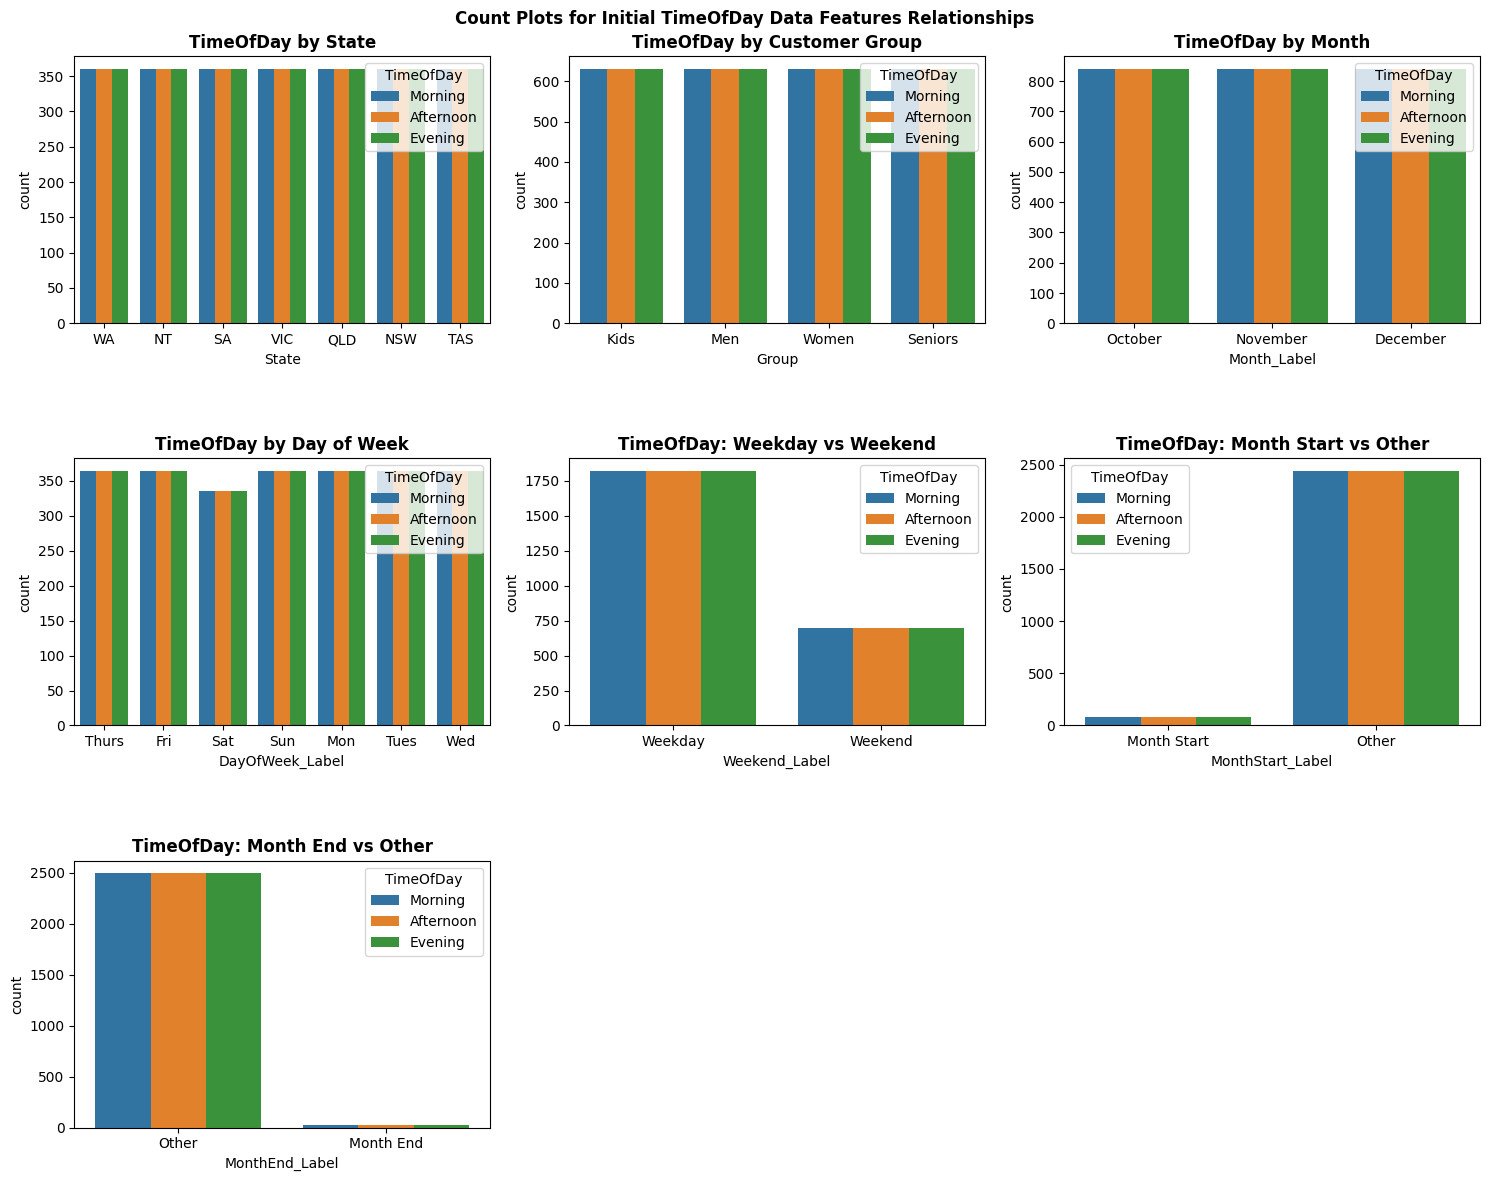

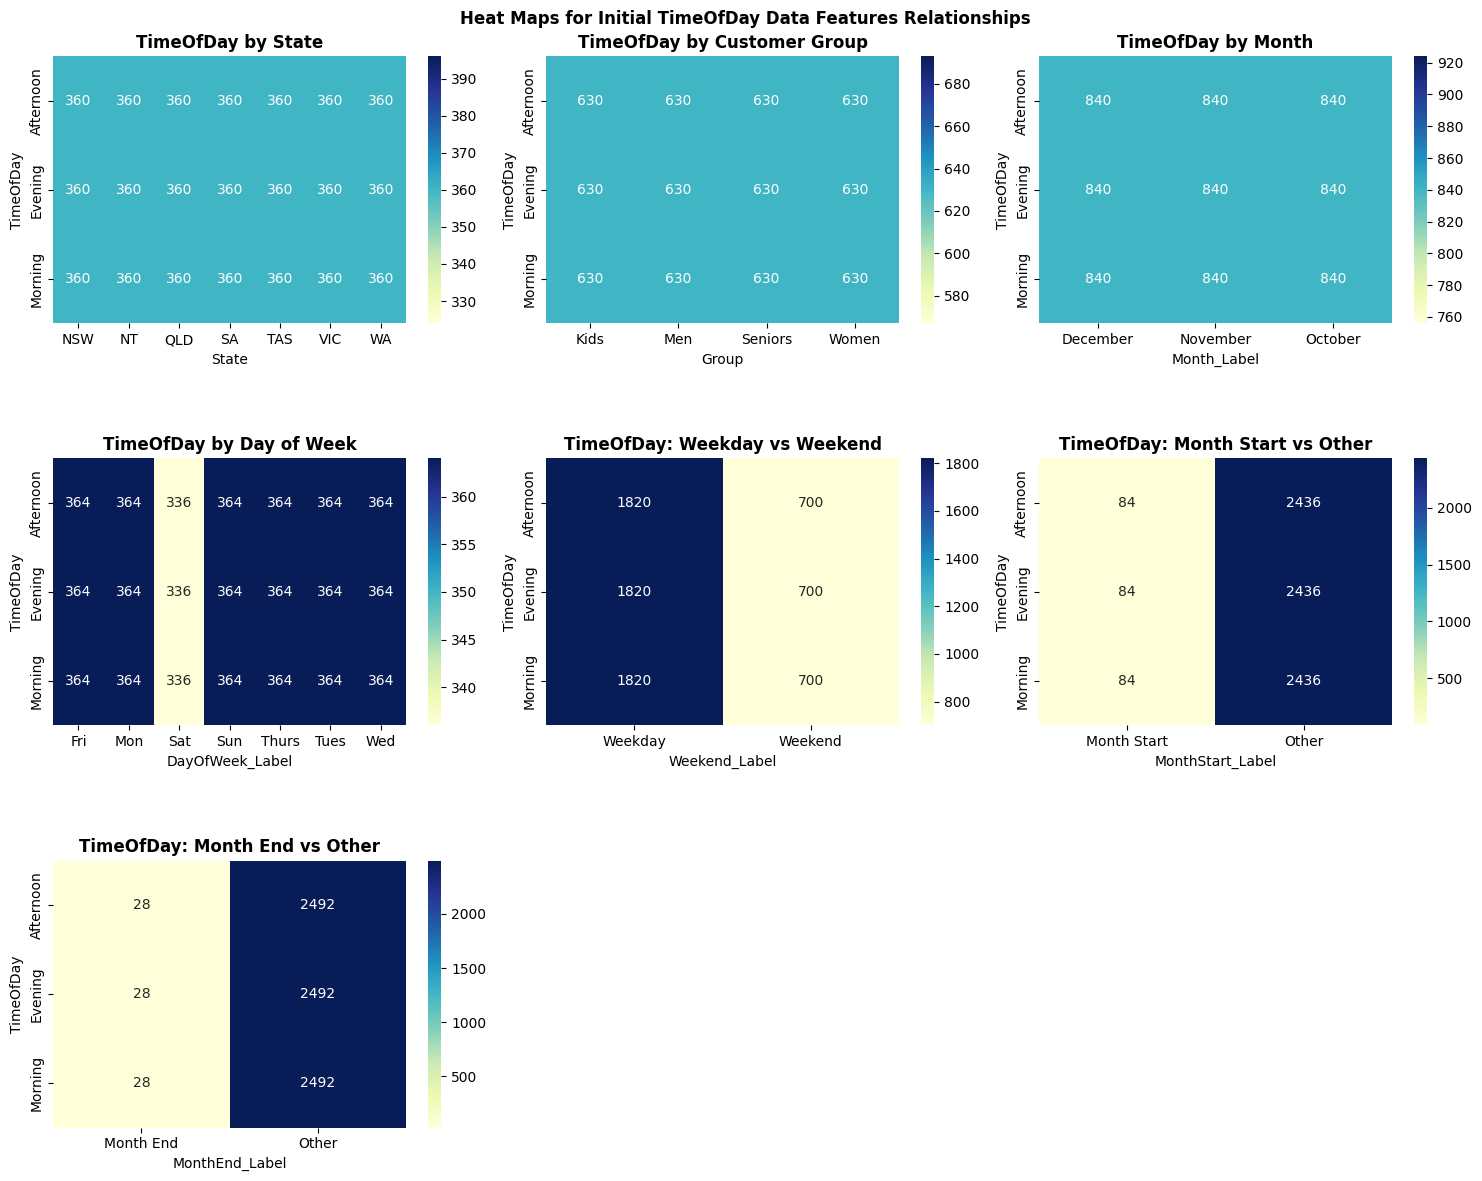

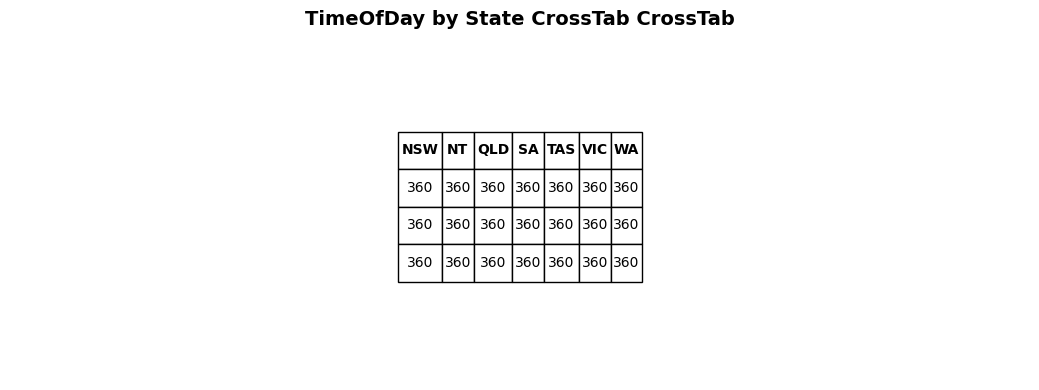

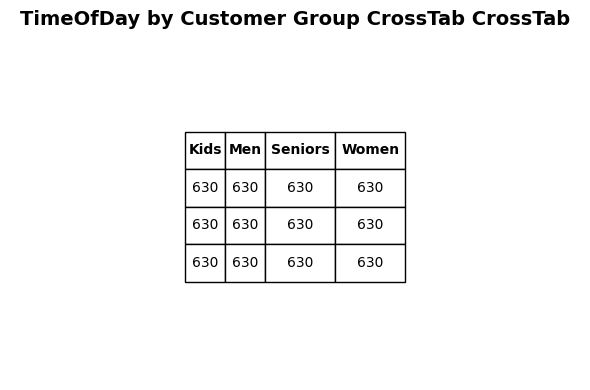

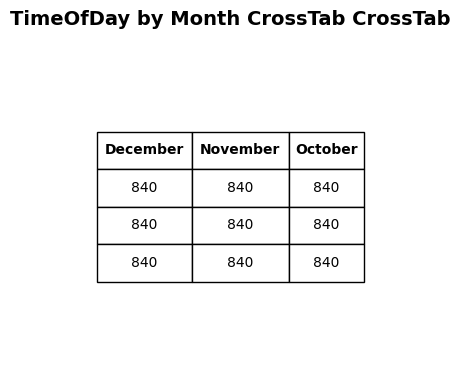

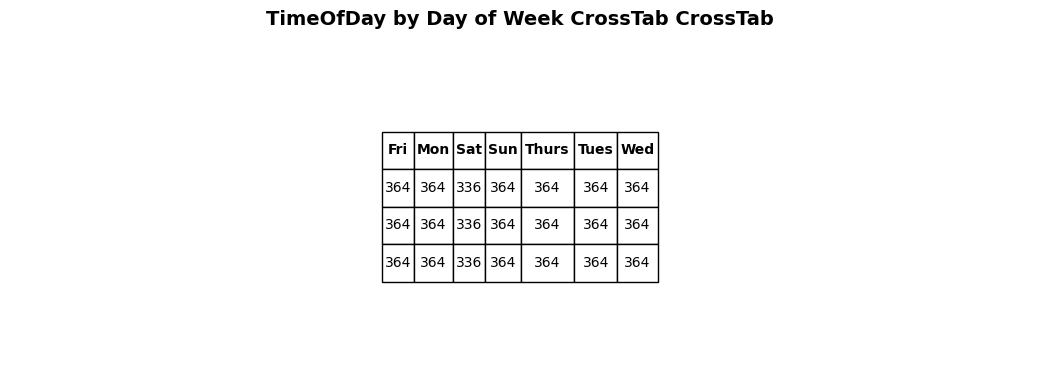

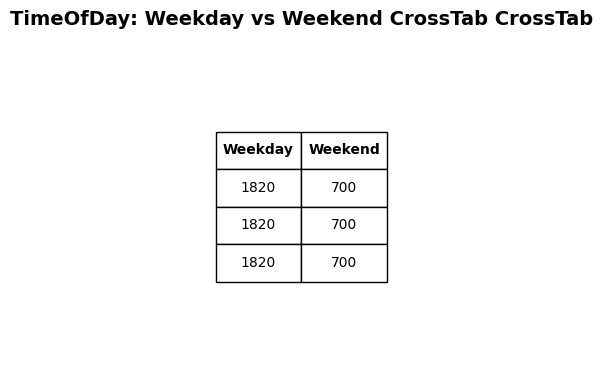

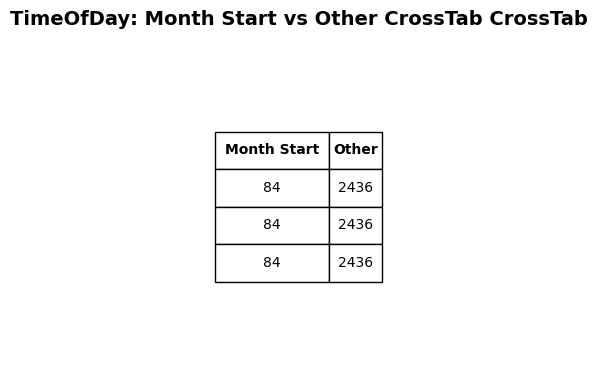

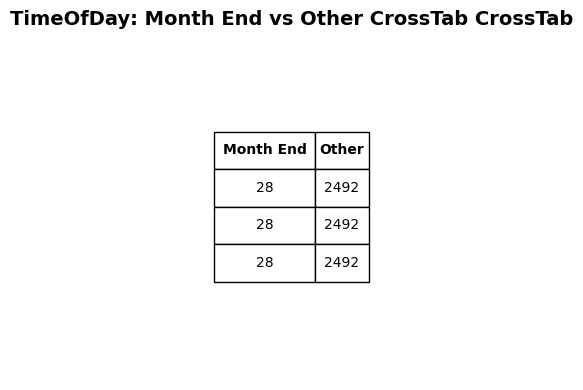

In [465]:

# Relational Box Plots for TimeOfDay
#

relationships_to_plot = [
    # Original categorical features
    {'XValue': 'State', 'YValue': 'TimeOfDay', 'Title': 'TimeOfDay by State'},
    {'XValue': 'Group', 'YValue': 'TimeOfDay', 'Title': 'TimeOfDay by Customer Group'},
    
    # Time-based features
    {'XValue': 'Month_Label', 'YValue': 'TimeOfDay', 'Title': 'TimeOfDay by Month'},
    {'XValue': 'DayOfWeek_Label', 'YValue': 'TimeOfDay', 'Title': 'TimeOfDay by Day of Week'},
    
    # Binary features
    {'XValue': 'Weekend_Label', 'YValue': 'TimeOfDay', 'Title': 'TimeOfDay: Weekday vs Weekend'},
    {'XValue': 'MonthStart_Label', 'YValue': 'TimeOfDay', 'Title': 'TimeOfDay: Month Start vs Other'},
    {'XValue': 'MonthEnd_Label', 'YValue': 'TimeOfDay', 'Title': 'TimeOfDay: Month End vs Other'},
]

PlotsToViewRelationships(df_ausapparalsales_with_date_features, 
                         relationships_to_plot, 
                         plot_title='Count Plots for Initial TimeOfDay Data Features Relationships', 
                         plot_type='CountPlot',
                         display_crosstab=True)

PlotsToViewRelationships(df_ausapparalsales_with_date_features, 
                         relationships_to_plot, 
                         plot_title='Heat Maps for Initial TimeOfDay Data Features Relationships', 
                         plot_type='HeatMap',
                         display_crosstab=True)

#### <b>Plots of Categorical Features versus Group Relativity</b> ####

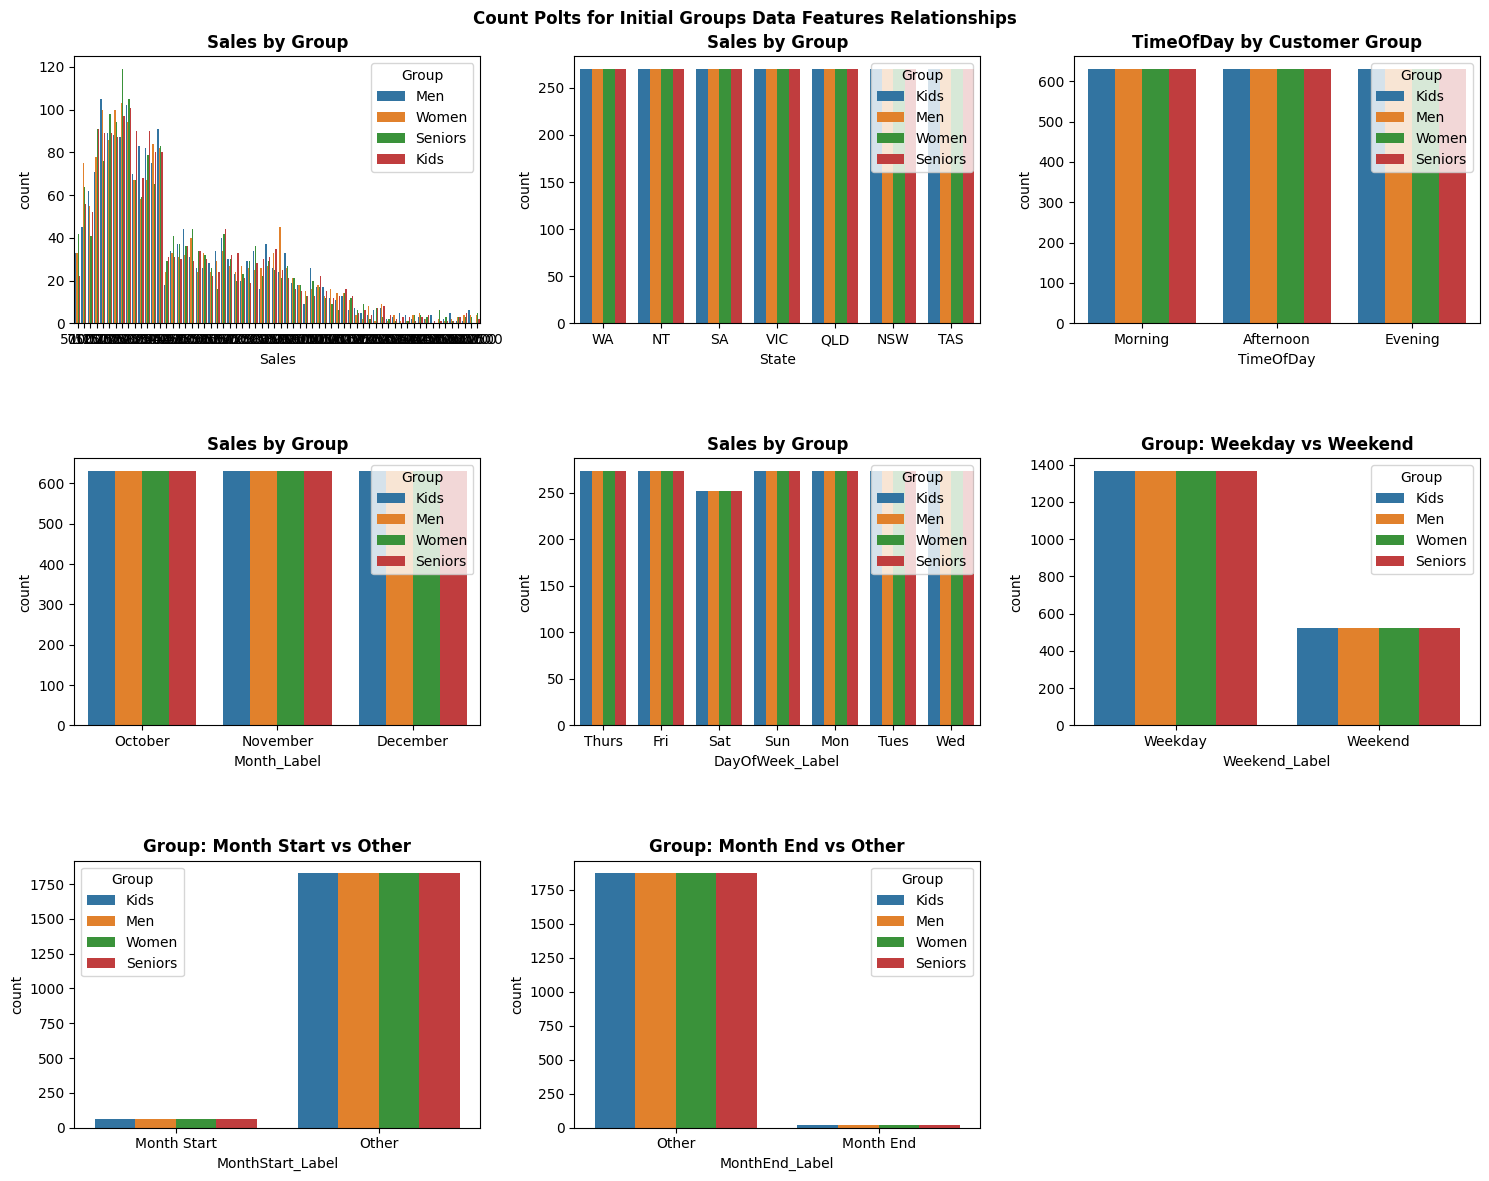

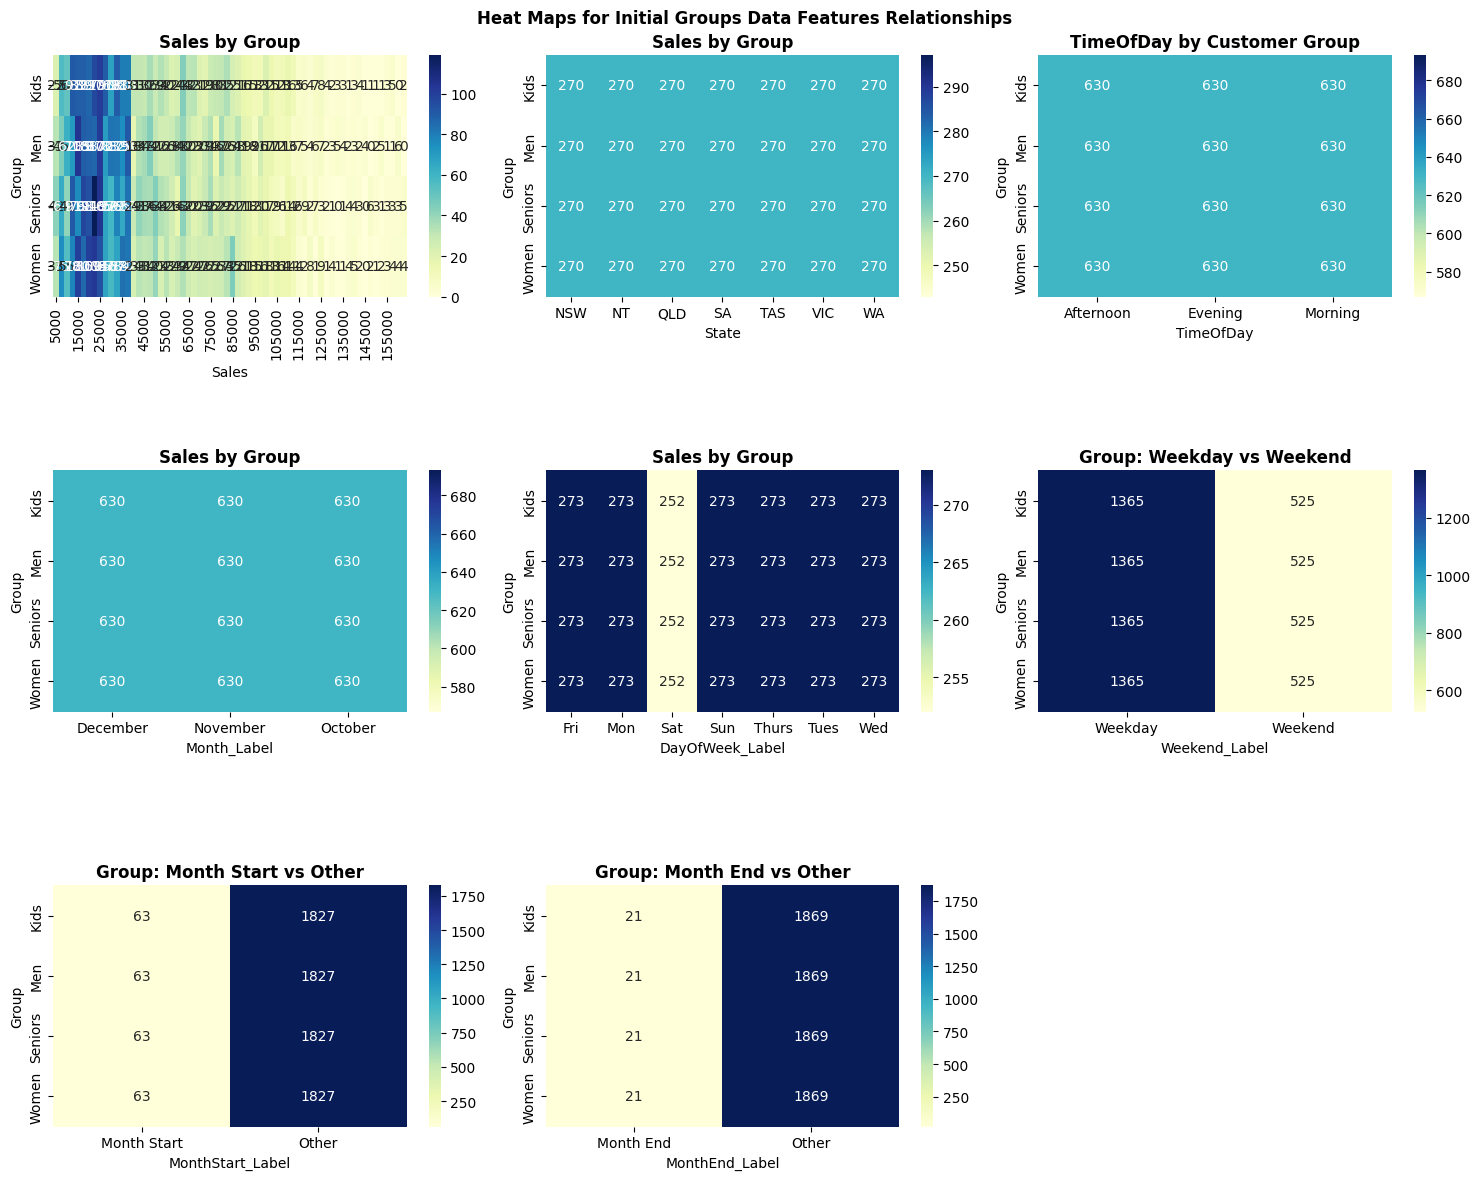

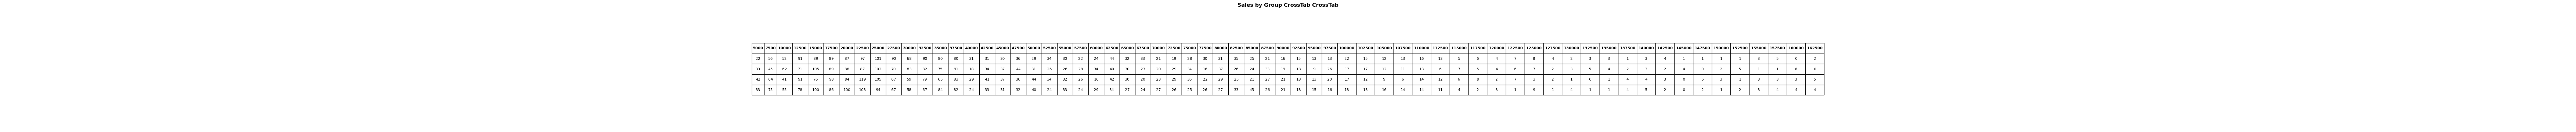

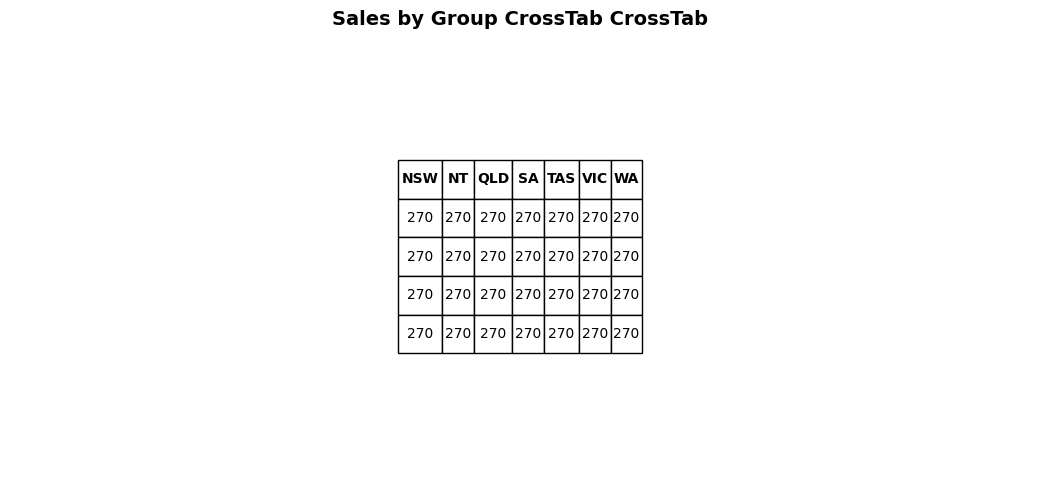

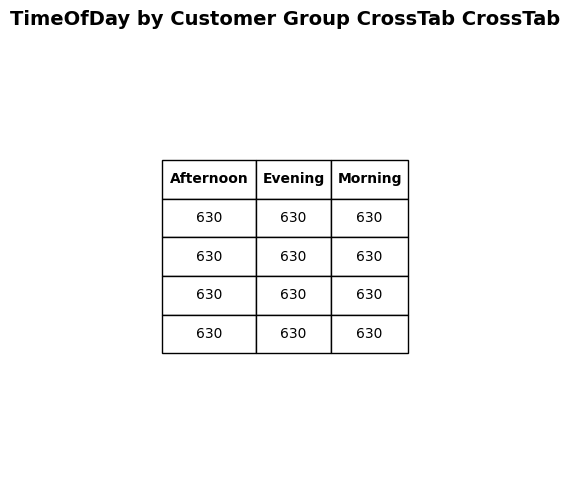

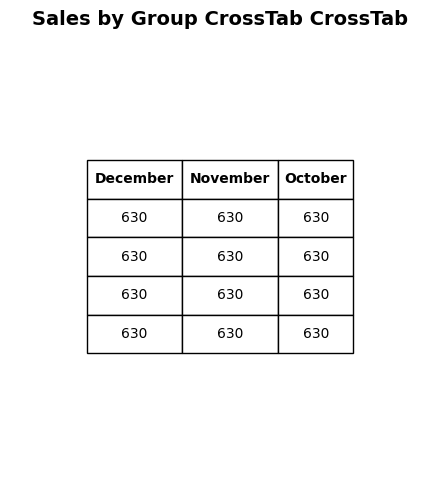

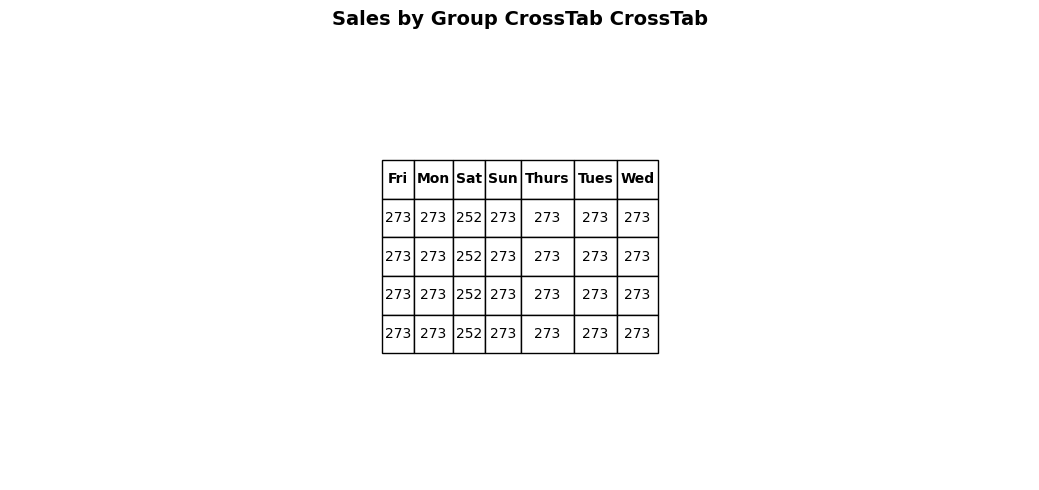

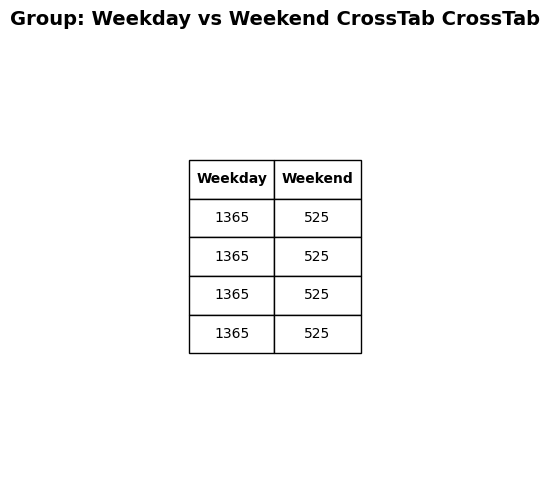

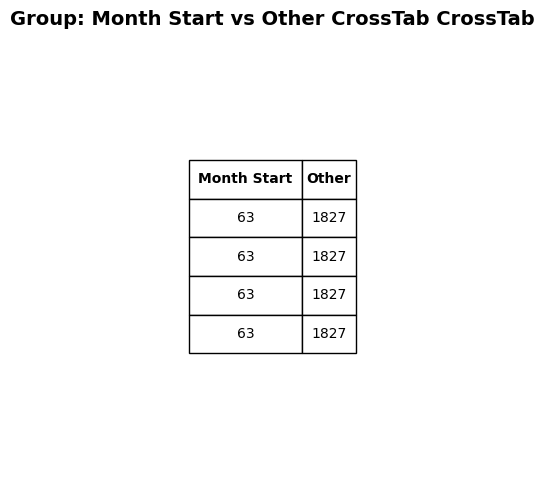

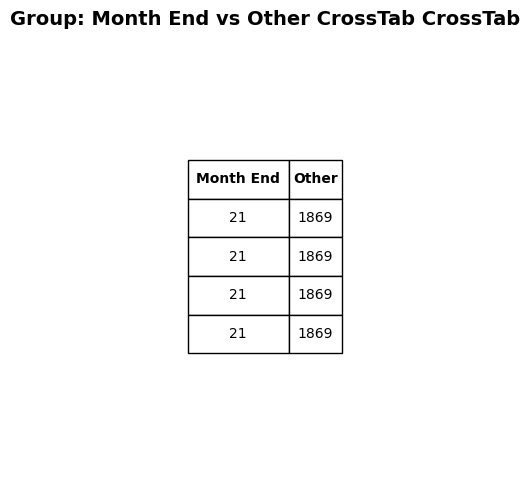

In [466]:
#
# Relational Box Plots for Groups
#

relationships_to_plot = [
    # Original categorical features
    {'XValue': 'Sales', 'YValue': 'Group', 'Title': 'Sales by Group'},
    {'XValue': 'State', 'YValue': 'Group', 'Title': 'Sales by Group'},
    {'XValue': 'TimeOfDay', 'YValue': 'Group', 'Title': 'TimeOfDay by Customer Group'},
    
    # Time-based features
    {'XValue': 'Month_Label', 'YValue': 'Group', 'Title': 'Sales by Group'},
    {'XValue': 'DayOfWeek_Label', 'YValue': 'Group', 'Title': 'Sales by Group'},
    
    # Binary features
    {'XValue': 'Weekend_Label', 'YValue': 'Group', 'Title': 'Group: Weekday vs Weekend'},
    {'XValue': 'MonthStart_Label', 'YValue': 'Group', 'Title': 'Group: Month Start vs Other'},
    {'XValue': 'MonthEnd_Label', 'YValue': 'Group', 'Title': 'Group: Month End vs Other'},
]

PlotsToViewRelationships(df_ausapparalsales_with_date_features, 
                         relationships_to_plot, 
                         plot_title='Count Polts for Initial Groups Data Features Relationships', 
                         plot_type='CountPlot',
                         display_crosstab=True)

PlotsToViewRelationships(df_ausapparalsales_with_date_features, 
                         relationships_to_plot, 
                         plot_title='Heat Maps for Initial Groups Data Features Relationships', 
                         plot_type='HeatMap',
                         display_crosstab=True)

#### <b>Plots of Categorical Features versus State Relativity</b> ####

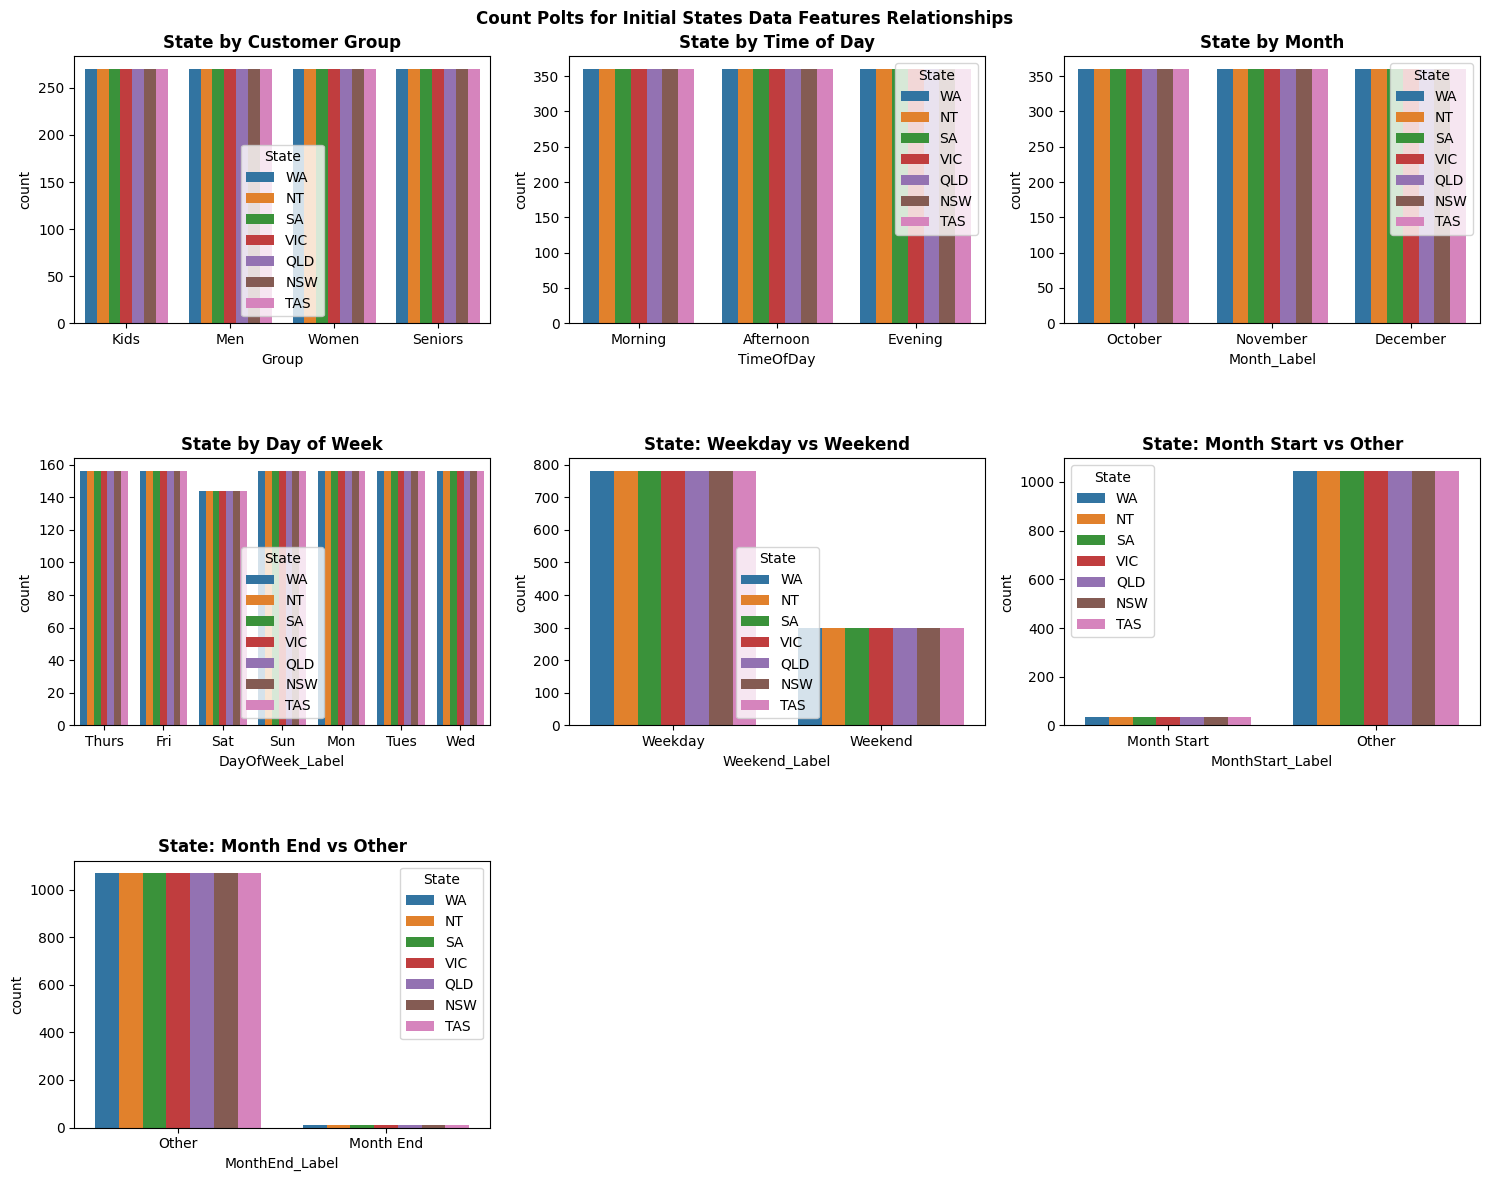

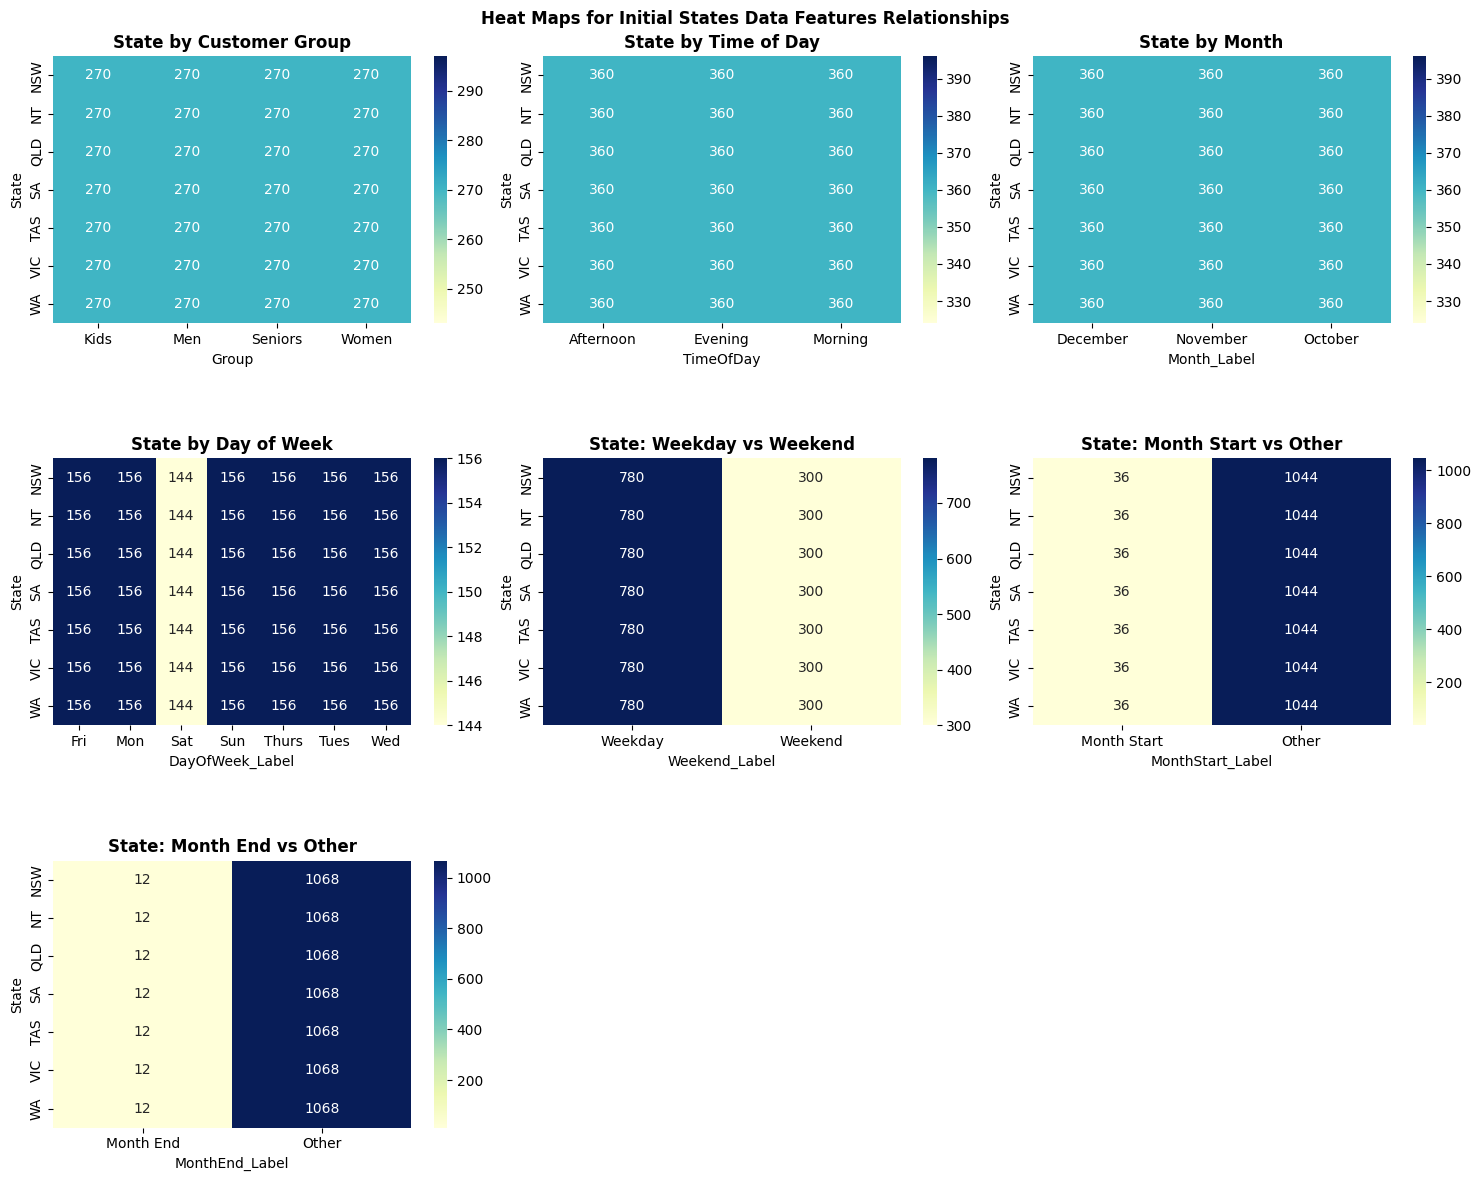

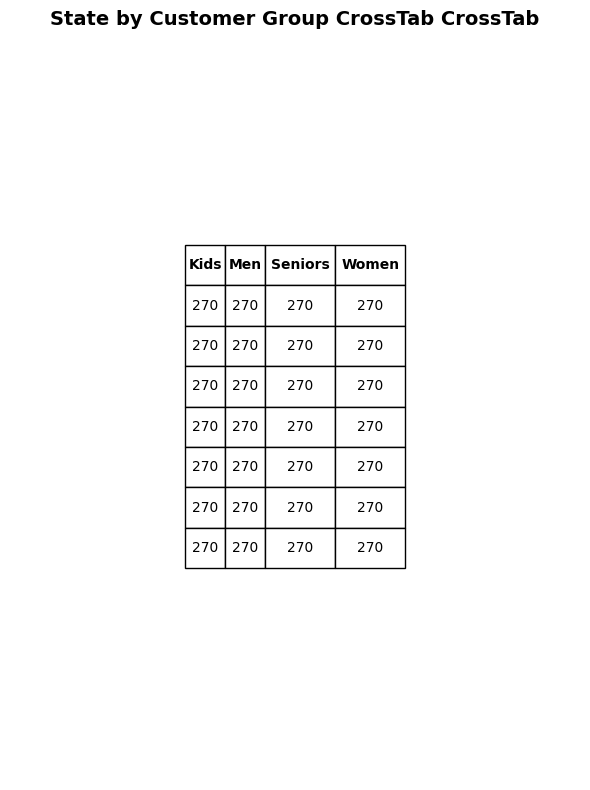

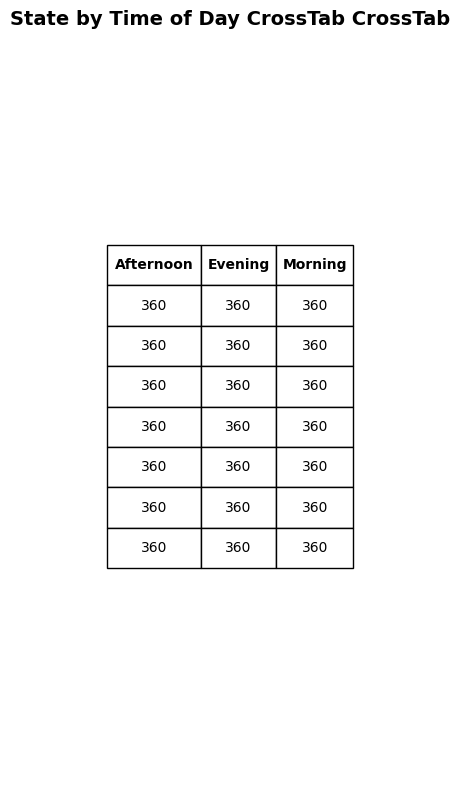

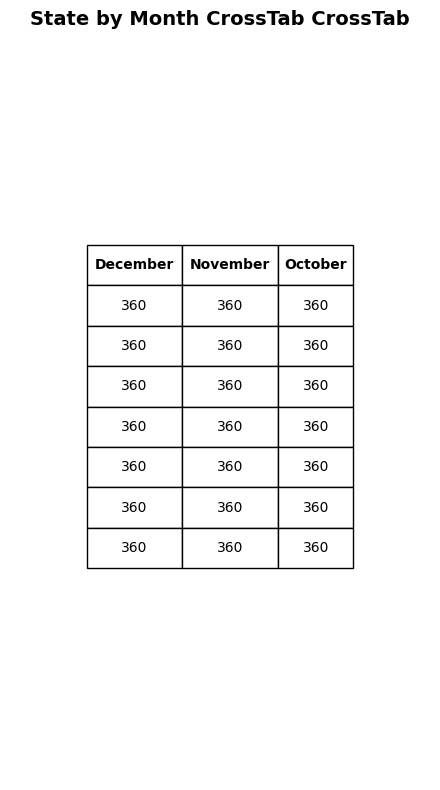

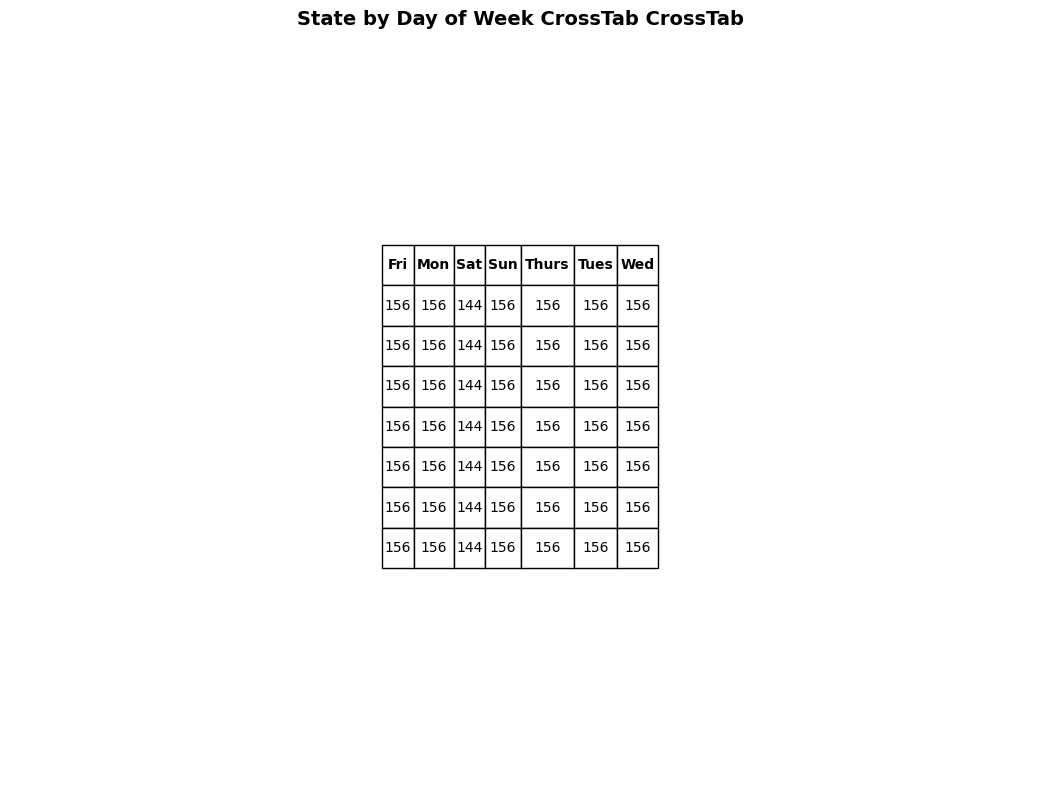

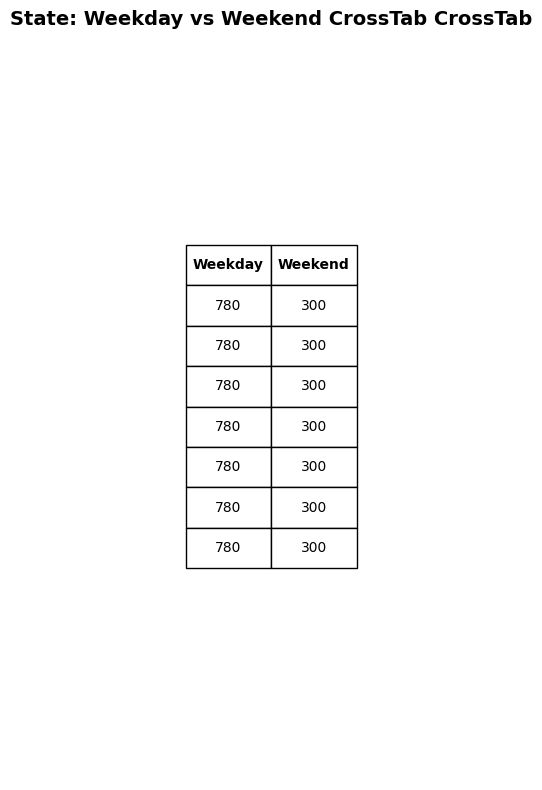

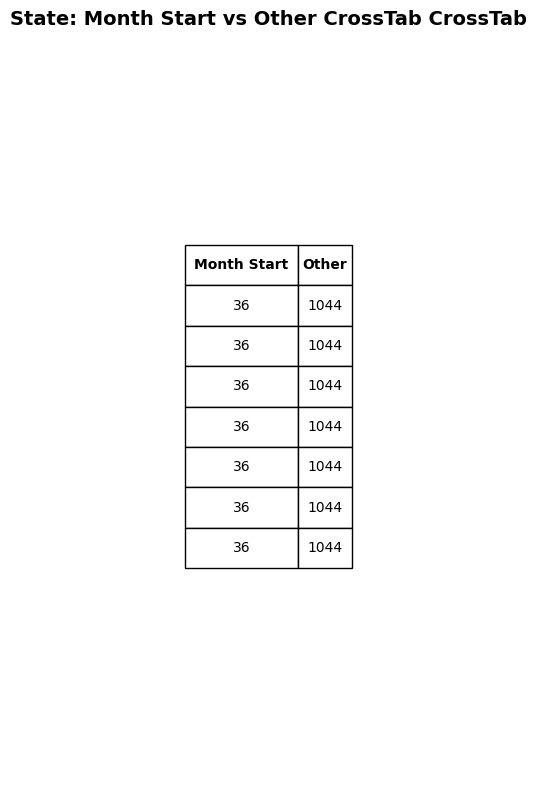

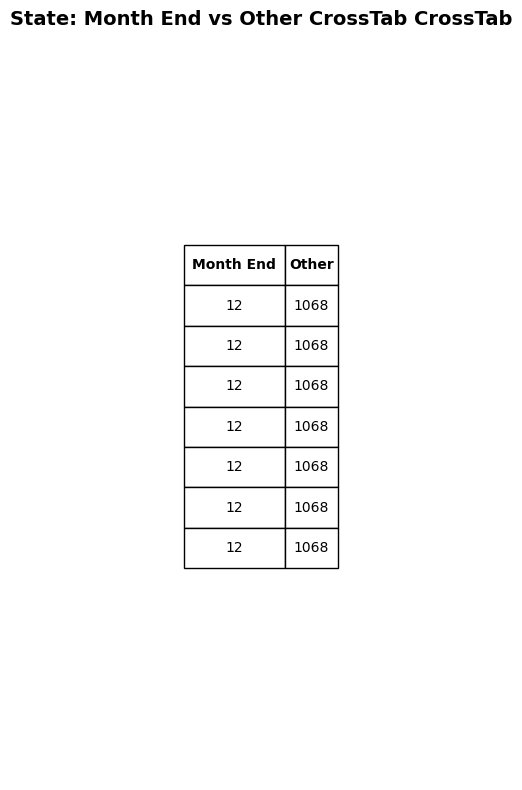

In [467]:
#
# Relational Box Plots for States
#

relationships_to_plot = [
    # Original categorical features
    {'XValue': 'Group', 'YValue': 'State', 'Title': 'State by Customer Group'},
    {'XValue': 'TimeOfDay', 'YValue': 'State', 'Title': 'State by Time of Day'},
    
    # Time-based features
    {'XValue': 'Month_Label', 'YValue': 'State', 'Title': 'State by Month'},
    {'XValue': 'DayOfWeek_Label', 'YValue': 'State', 'Title': 'State by Day of Week'},
    
    # Binary features
    {'XValue': 'Weekend_Label', 'YValue': 'State', 'Title': 'State: Weekday vs Weekend'},
    {'XValue': 'MonthStart_Label', 'YValue': 'State', 'Title': 'State: Month Start vs Other'},
    {'XValue': 'MonthEnd_Label', 'YValue': 'State', 'Title': 'State: Month End vs Other'},
]

PlotsToViewRelationships(df_ausapparalsales_with_date_features, 
                         relationships_to_plot, 
                         plot_title='Count Polts for Initial States Data Features Relationships', 
                         plot_type='CountPlot',
                         display_crosstab=True)

PlotsToViewRelationships(df_ausapparalsales_with_date_features, 
                         relationships_to_plot, 
                         plot_title='Heat Maps for Initial States Data Features Relationships', 
                         plot_type='HeatMap',
                         display_crosstab=True)

### **Encode the Categorical Features** ###    

In [468]:
#
# Call Encoder function
#
df_ausapparalsales_new = EncodeCategoricalFeatures(df_ausapparalsales_new)
#PrintDataFrameStatus(df_ausapparalsales_new)

Ordinal encoding mapping:


#### <b>Data Type Conversion</b> ####
    The next step is to convert data types into optimal performance types
        Unit                int64          ==> int8
        Sales               int64          ==> int32
        Month               int32          ==> int8
        DayOfWeek           int32          ==> int8
        Day                 int32          ==> int16
        WeekOfYear          UInt32         ==> int8
        Weekend             int64          ==> int8
        State_NT            float64        ==> int8
        State_QLD           float64        ==> int8
        State_SA            float64        ==> int8
        State_TAS           float64        ==> int8
        State_VIC           float64        ==> int8
        State_WA            float64        ==> int8
        Group_Men           float64        ==> int8
        Group_Seniors       float64        ==> int8
        Group_Women         float64        ==> int8
        TimeOfDay_encoded   float64        ==> int8 


In [469]:
# Data Type Conversions

# int8 Conversions
columns = ['Unit','Month','DayOfWeek','WeekOfYear','Weekend','State_NT',
            'State_QLD','State_SA','State_TAS','State_VIC','State_WA',
            'Group_Men','Group_Seniors','Group_Women','TimeOfDay_encoded']
df_ausapparalsales_new[columns] = df_ausapparalsales_new[columns].astype('int8')

# int16 Conversions
columns = ['Day']
df_ausapparalsales_new[columns] = df_ausapparalsales_new[columns].astype('int16')

# int32 Conversions
columns = ['Sales']
df_ausapparalsales_new[columns] = df_ausapparalsales_new[columns].astype('int16')
#PrintDataFrameStatus(df_ausapparalsales_new)

KeyError: "None of [Index(['Day'], dtype='object')] are in the [columns]"

#### <b>Box Plots of Feature Relationships to Identify Trends</b> ####

In [ ]:
#
# Relational Box Plots
#

relationships_to_plot = [
                            {'XValue': 'State', 'YValue': 'Sales', 'Title': 'Sales by State'},
                            {'XValue': 'Group', 'YValue': 'Sales', 'Title': 'Sales by Group'},
                            {'XValue': 'TimeOfDay', 'YValue': 'Sales', 'Title': 'Sales by Time'}
                        ]

PrintDataFrameStatus(df_ausapparalsales_new)
print()

#PlotBoxPlotsToViewRelationships(df_ausapparalsales_new, relationships_to_plot, plot_title='Box Plots for Initial Sales Data Features Relationships')

### Plot the original "Dirty Data" to see distributions ###
#### Feature Distributions for Numerical Columns-- Histograms ####

In [ ]:
# The columns we want to plot:
print('Numeric Feature Columns to plot')
numeric_cols = df_NSME1988_dirty.select_dtypes(include=['number']).columns.tolist()
print(numeric_cols)

def PlotHistogramsToViewDistributions(df_dataset):
    n_cols = len(numeric_cols)
    print(f'Number of Columns: {n_cols}')

    fig, axes = plt.subplots(nrows=(n_cols + 2) // 3, ncols=3, figsize=(15, 5 * ((n_cols + 2) // 3)))
    axes = axes.flatten()

    plt.suptitle('Raw Feature Distributions - Non-Normailzed', fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.90])  # Leave space at top

    #Iterate over each numeric column and plot a historgram
    for i, col in enumerate(numeric_cols):
        sns.histplot(data=df_dataset, x=col, ax=axes[i], kde=True)    
        axes[i].set_title(col, fontweight='bold')

        # Calculate statistics
        mean_val = df_dataset[col].mean()
        median_val = df_dataset[col].median()
        mode_val = df_dataset[col].mode()[0] if not df_dataset[col].mode().empty else None
        std_val = df_dataset[col].std()

        # Plot Statistics as Vertical Lines
        axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
        axes[i].axvline(median_val, color='green', linestyle='--', linewidth=2, label=f'Median: {median_val:.2f}')
        if mode_val is not None:
            axes[i].axvline(mode_val, color='blue', linestyle='--', linewidth=2, label=f'Mode: {mode_val:.2f}')
        
        # Add std as shaded region around mean
        axes[i].axvspan(mean_val - std_val, mean_val + std_val, alpha=0.2, color='gray', label=f'Std: {std_val:.2f}')
        
        # Add legend
        axes[i].legend(fontsize=8, loc='upper right')


    # Make plots more readable and add space
    plt.tight_layout(h_pad=5)
    plt.show()   


PlotHistogramsToViewDistributions(df_NSME1988_dirty)


##### Histogram Analysis #####
    1. The following columns' distribution is right skewed (indicating the presence of outliers).
        This will have to be fixed via cropping as we seek a more normalized distribution.
        visits      
        nvisits     
        ovisits     
        novisits    
        emergency   
        hospital    
        chronic     
        age         
        school      
        income       
        insurance
    2. Age does not follow this pattern. It looks like a more normal or bimodal distribution.


#### Box Plots for Numerical Columns-- Identify Outliers ####

In [ ]:

def PlotBoxPlotsToViewDistributions(df_dataset):
    n_cols = len(numeric_cols)

    fig, axes = plt.subplots(nrows=(n_cols + 2) // 3, ncols=3, figsize=(15, 5 * ((n_cols + 2) // 3)))
    axes = axes.flatten()

    plt.suptitle('Raw Feature Distributions - Box Plots', fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.90])  # Leave space at top

    #Iterate over each numeric column and plot a historgram
    for i, col in enumerate(numeric_cols):
        sns.boxplot(data=df_dataset, y=col, ax=axes[i])    
        axes[i].set_title(col, fontweight='bold')

        # Optional: Add count of outliers
        Q1 = df_dataset[col].quantile(0.25)
        Q3 = df_dataset[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        outlier_count = len(df_dataset[(df_dataset[col] < lower) | 
                                            (df_dataset[col] > upper)])
        axes[i].text(0.5, 0.95, f'Outliers: {outlier_count}', 
                    transform=axes[i].transAxes, ha='center', fontsize=9, fontweight='bold')

    # Make plots more readable and add space
    plt.tight_layout(h_pad=5)
    plt.show()   

PlotBoxPlotsToViewDistributions(df_NSME1988_dirty)

##### BoxPlot Analysis #####
    1. The boxplots reinforce the histograms results, indicating outliers in the higher values (which relate to right skewedness).
    The outliers indicate a high volume of outliers (lots of circles above the box).
    The boxes for most of them look pretty small which indicates the median is close to zero (0).
    It looks like healthcare resources aren't heavily used.
        visits      
        nvisits     
        ovisits     
        novisits    
        emergency   
        hospital    
        chronic     
        age         
        school      
        income       
        insurance
    2. School looks like it's got some outliers at the lower values, which would point to a left skew with some lower valued outliers.
       I don't think we want to fix (crop) this because lower education could very well be a predicator and have some significance.


In [ ]:
# Examine value ranges for numeric columns
#

summary = pd.DataFrame()

for i, col in enumerate(numeric_cols):
    summary = df_NSME1988_dirty[numeric_cols].describe().loc[['min', '25%', '50%', '75%', 'max']]
    
print(summary)

sns.heatmap(df_NSME1988_dirty.isnull(), cbar=False, yticklabels=False)
plt.show()

##### Range Analysis #####
    1. We have some bad/incorrect data with the following columns registering a count 0f -1 (You can't have -1 visits)
        visits      
        nvisits     
        ovisits     
        novisits    
    2. The following columns look suspect because 3/4 of their quantiles are showing 0 with values skewed to max
        emergency
        hospital
    3. I can do a heatmap to show the missing data in the dataframe (numeric columns).
    The heatmap is a plot of missing data in the numeric columns. Visually it looks like we have a fair amount of missing data.

In [ ]:
#
# grubbs_test - Found this on internet when searching for methods
#
#
def grubbs_test(data):
    """
    Performs Grubbs' test for outliers on a dataset
    Tests if the most extreme value is an outlier
    
    Returns: G statistic and p-value
    """
    # Remove NaN values
    data = data.dropna()
    
    # Calculate mean and standard deviation
    mean = np.mean(data)
    std = np.std(data, ddof=1)
    n = len(data)
    
    # Calculate G statistic (max deviation from mean in std units)
    G = np.max(np.abs(data - mean)) / std
    
    # Calculate p-value using t-distribution
    t_stat = G * np.sqrt(n-2) / np.sqrt(n-1-G**2)
    p_value = 2 * (1 - t.cdf(abs(t_stat), n-2))
    
    return G, p_value


def run_grubbs_test():
    # Print skewness
    for col in numeric_cols:
        print(f"{col}: Skewness: {df_NSME1988_dirty[col].skew():.2f}")

    print()
    print('----------------------------------------------------------')
    print()

    for col in numeric_cols:
        print(f"\n{'='*60}")
        print(f"Column: {col}")
        print(f"{'='*60}")
        
        # Original skewness
        orig_skew = df_NSME1988_dirty[col].skew()
        print(f"Original skewness: {orig_skew:.2f}")
        
        # Log transform (log1p handles zeros)
        log_data = np.log1p(df_NSME1988_dirty[col].dropna())
        log_skew = stats.skew(log_data)
        print(f"Log-transformed skewness: {log_skew:.2f}")
        
        # Now apply Grubbs test on transformed data
        if abs(log_skew) < 1:  # Check if transformation worked
            G, p_val = grubbs_test(log_data)
            print(f"Grubbs G-statistic: {G:.4f}")
            print(f"P-value: {p_val:.4f}")
            
            if p_val < 0.05:
                print("Conclusion: Significant outlier detected (p < 0.05)")
            else:
                print("Conclusion: No significant outlier (p ≥ 0.05)")
        else:
            print("Still too skewed even after log transformation")


run_grubbs_test()

##### Prove/Disprove which numeric columns contain outliers ######
    We want to provide some statisical analysis that proves whether the data truly contains extreme outliers (data errors) or the values are
    are within within legitmate ranges.

    The data is heavily right skewed. So we can't directly apply Z-Score, so I did some research and found a custom implementation of grubbs_test()
    which returns the max deviation from the mean and a p_value.

    Data is too skewed, so we first applied log transformation in order to make the distribution more normal. 
    This stil didn't work particularly well as all the columns (except for chronic) were too skewed.
    For 'chronic' we got a P-Value of 0.0088 (p < 0.05) indicating it detected an outlier.

    To try to overcome this, I will try additional (Power) transformations:
        - Square root transformation
        - Yeo-Johnson transformation 
        - Box-Cox transformation  - Since we have negative values we won't use Box-Cox

In [ ]:
# Store the results in a data frame
results = pd.DataFrame(columns=['Original', 'Square Root', 'Yeo-Johnson'])

for col in numeric_cols:
    
    original = df_NSME1988_dirty[col].dropna()
    
    # Apply transformations
    sqrt_data = np.sqrt(original)
    yeojohnson_data, _ = yeojohnson(original)
    
    # Store skewness values
    results.loc[col] = [
        original.skew(),
        sqrt_data.skew(),
        pd.Series(yeojohnson_data).skew()
    ]

print('Results of applying Power Transforms')
print('-----------------------------------------')
print(results)

##### Analysis of Applied Transformations #####
    Based on the results of applying sqrt and Yeo-Johnson:

                    Original   Square Root  Yeo-Johnson
        visits      3.611181     0.616842    -0.013211
        nvisits     7.538863     2.533991    -0.417325
        ovisits    19.561863     3.759981    -1.306321
        novisits   23.646347     5.781900    -1.614963
        emergency   5.040876     2.066182     1.638413
        hospital    3.971046     1.956877     1.525857
        chronic     1.012530    -0.321434    -0.012175
        age         7.413582     6.466510     0.000000
        school     -0.453236    -1.905147    -0.109121
        income      5.813436     1.787623    -0.098247

    It looks like Yeo-Johnson transformation provided the best results.
    The p-values look much more reasonable.

##### Plot the results of Yeo-Johnson Transformation #####


In [ ]:
#
# Plot original and  Yeo-Johnson transformation to all the numeric columns
#


n_rows = len(numeric_cols)

fig, axes = plt.subplots(nrows=n_rows, ncols=2, figsize=(15, 5 * n_rows))
axes = axes.flatten()

plt.suptitle('Original vs Yeo-Johnson Transformations', fontweight='bold', fontsize=16)

# Iterate over each numeric column
plot_idx = 0
for col in numeric_cols:
    # Original data
    original = df_NSME1988_dirty[col].dropna()
    
    # ORIGINAL PLOT
    sns.histplot(data=df_NSME1988_dirty, x=col, ax=axes[plot_idx], kde=True)    
    axes[plot_idx].set_title(f'{col} - Original', fontweight='bold')

    # Calculate statistics for original
    mean_val = original.mean()
    median_val = original.median()
    mode_val = original.mode()[0] if not original.mode().empty else None
    std_val = original.std()

    # Plot Statistics as Vertical Lines
    axes[plot_idx].axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
    axes[plot_idx].axvline(median_val, color='green', linestyle='--', linewidth=2, label=f'Median: {median_val:.2f}')
    if mode_val is not None:
        axes[plot_idx].axvline(mode_val, color='blue', linestyle='--', linewidth=2, label=f'Mode: {mode_val:.2f}')
    
    # Add std as shaded region around mean
    axes[plot_idx].axvspan(mean_val - std_val, mean_val + std_val, alpha=0.2, color='gray', label=f'Std: {std_val:.2f}')
    axes[plot_idx].legend(fontsize=8, loc='upper right')
    
    plot_idx += 1
    
    # YEO-JOHNSON TRANSFORMED PLOT
    yeojohnson_data, yj_lambda = yeojohnson(original)
    yj_series = pd.Series(yeojohnson_data)
    
    sns.histplot(yj_series, ax=axes[plot_idx], kde=True, color='red')
    axes[plot_idx].set_title(f'{col} - Yeo-Johnson (λ={yj_lambda:.2f}, skew={yj_series.skew():.2f})', fontweight='bold')
    
    # Calculate statistics for transformed
    mean_yj = yj_series.mean()
    median_yj = yj_series.median()
    mode_yj = yj_series.mode()[0] if not yj_series.mode().empty else None
    std_yj = yj_series.std()
    
    # Plot Statistics as Vertical Lines
    axes[plot_idx].axvline(mean_yj, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_yj:.2f}')
    axes[plot_idx].axvline(median_yj, color='green', linestyle='--', linewidth=2, label=f'Median: {median_yj:.2f}')
    if mode_yj is not None:
        axes[plot_idx].axvline(mode_yj, color='blue', linestyle='--', linewidth=2, label=f'Mode: {mode_yj:.2f}')
    
    # Add std as shaded region around mean
    axes[plot_idx].axvspan(mean_yj - std_yj, mean_yj + std_yj, alpha=0.2, color='gray', label=f'Std: {std_yj:.2f}')
    axes[plot_idx].legend(fontsize=8, loc='upper right')
    
    plot_idx += 1

# Hide any unused subplots
for idx in range(plot_idx, len(axes)):
    axes[idx].set_visible(False)

# Make plots more readable and add space
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [ ]:
# 
# grubbs_test for transformed data
#
def run_grubbs_test_for_transformed_data():

    # Run Grubbs test on transformed data
    for col in numeric_cols:
        print(f"\n{'='*60}")
        print(f"Column: {col}")
        print(f"{'='*60}")
        
        # Get original data
        original = df_NSME1988_dirty[col].dropna()
        
        # Apply Yeo-Johnson transformation
        yeojohnson_data, yj_lambda = yeojohnson(original)
        yj_series = pd.Series(yeojohnson_data)
        
        # Check if transformation improved normality
        orig_skew = original.skew()
        yj_skew = yj_series.skew()
        
        print(f"Original skewness: {orig_skew:.2f}")
        print(f"Transformed skewness: {yj_skew:.2f}")
        print(f"Lambda: {yj_lambda:.2f}")
        
        # Run Grubbs test on transformed data
        if abs(yj_skew) < 1:  # Reasonably normal
            G, p_val = grubbs_test(yj_series)
            print(f"\nGrubbs Test Results:")
            print(f"  G-statistic: {G:.4f}")
            print(f"  P-value: {p_val:.4f}")
            
            if p_val < 0.05:
                print(f"  ✓ Significant outlier detected (p < 0.05)")
            else:
                print(f"  ✗ No significant outlier detected (p ≥ 0.05)")
        else:
            print(f"\n⚠ Still too skewed (|{yj_skew:.2f}| >= 1) for reliable parametric test")


#
# Rerun Initial grubbs_test
#

run_grubbs_test_for_transformed_data()

## <u>**2. Data Wrangling**</u> ##

### Clean Up Missing Data Issues ###
    In our case we've previously identified that the columns with missing data are of type float.
    We want to determine which data replacement strategy works best with our data.
    We have the following replacement techniques available to us:
- **Mean imputation**: Replace missing values with the column mean
- **Median imputation**: Replace missing values with the column median
- **KNN imputation**: Use K-Nearest Neighbors to estimate missing values
- **Iterative imputation**: Model each feature as a function of others (MICE algorithm)

## ##
    What we really want to do is apply the different techniques and then determine which one works best for our needs.
    We could do this 2 ways:
- **Apply the same method for the desired columns** </br>
(Simpler/Faster)
- **Iterate through the columns one by one to determine what is best for each column** </br>
(More Precise, but doesn't make sense for all strategies - KNN/Mice use other columns)

## ##
    For expediency and simplification purposes, we will use the same missing data replacement technique across columns.

    To find the best technique, we must test against known data. 
    To that end, we'll create a sample data set void of rows with missing data.
    We'll make a copy of that data set (A). Next we'll making a second data set A and randomly
    create missing values across the columsn of interest.
    Then we will run our selected replacement strategies capturing the results (with missing data replaced).
    We then compare our original sample (A) against the modified samples and determine which technique works best.


##### Filter out existing rows with missing data - create dataset copy with manufactured missing rows#####

In [ ]:
#
# Count the number of "complete/clean" rows of data and number of rows that have missing data
#

columns_with_missing_data = ['visits','nvisits','ovisits','novisits','emergency',
                            'hospital','chronic','age','school','income']
complete_rows = df_NSME1988_dirty[columns_with_missing_data].dropna()
rows_with_missing_data = df_NSME1988_dirty[df_NSME1988_dirty[columns_with_missing_data].isnull().any(axis=1)]

print(f"Complete rows: {len(complete_rows)}")
print(f"Rows with missing data: {len(rows_with_missing_data)}")


# Create artificial missingness
test_data = complete_rows.copy()
np.random.seed(42)
missing_mask = np.random.random(test_data.shape) < 0.10
true_values = test_data.values[missing_mask]
test_data.values[missing_mask] = np.nan

# Test all methods
results = {}

print(df_NSME1988_dirty.head(20))

# Mean (all columns)
mean_imp = SimpleImputer(strategy='mean')
results['Mean'] = mean_absolute_error(true_values, mean_imp.fit_transform(test_data)[missing_mask])

# Median (all columns)
median_imp = SimpleImputer(strategy='median')
results['Median'] = mean_absolute_error(true_values, median_imp.fit_transform(test_data)[missing_mask])

# KNN (uses relationships between columns)
knn_imp = KNNImputer(n_neighbors=5)
results['KNN'] = mean_absolute_error(true_values, knn_imp.fit_transform(test_data)[missing_mask])

# MICE (uses relationships between columns)
mice_imp = IterativeImputer(random_state=42)
results['MICE'] = mean_absolute_error(true_values, mice_imp.fit_transform(test_data)[missing_mask])

# Winner
print('---------------------------------------------------------')
print('Imputation Results')
print(results)
print('--------------------------------------------------------')
best = min(results, key=results.get)
print(f"Best method: {best}")

#
# For additional analysis, let's run the imputations and plot results against originals
#

df_mean = df_NSME1988_dirty.copy()
df_median = df_NSME1988_dirty.copy()

for col in columns_with_missing_data:

    # Mean Imputation
    df_mean.fillna({col: df_mean[col].mean()}, inplace=True)

    # Median Imputation
    df_median.fillna({col: df_median[col].median()}, inplace=True)

# KNN Imputation (all columns at once)
knn_imputer = KNNImputer(n_neighbors=5)
knn_array = knn_imputer.fit_transform(df_NSME1988_dirty[columns_with_missing_data])

# Convert entire result to DataFrame
df_knn = pd.DataFrame(
    knn_array,
    columns=columns_with_missing_data,
    index=df_NSME1988_dirty.index
)    

# Iterative Imputation
iterative_imputer = IterativeImputer(max_iter=10, random_state=42)
iterative_array = iterative_imputer.fit_transform(df_NSME1988_dirty[numeric_cols])

# Convert back to DataFrame
df_iterative = pd.DataFrame(
    iterative_array,
    columns=numeric_cols,
    index=df_NSME1988_dirty.index
)


n_rows = len(columns_with_missing_data)

fig, axes = plt.subplots(nrows=n_rows, ncols=4, figsize=(15, 5 * n_rows))
axes = axes.flatten()

# Define imputation methods and their properties
imputation_methods = [
    {'data': df_mean, 'title': 'Mean Imputation', 'color': 'green', 'label': 'Mean Imputed'},
    {'data': df_median, 'title': 'Median Imputation', 'color': 'orange', 'label': 'Median Imputed'},
    {'data': df_knn, 'title': 'KNN Imputation', 'color': 'purple', 'label': 'KNN Imputed'},
    {'data': df_iterative, 'title': 'Iterative Imputation', 'color': 'teal', 'label': 'Iterative Imputed'}
]

pltIdx = 0

for col in columns_with_missing_data:

    # Create KDE of original distribution
    kde_original = stats.gaussian_kde(df_NSME1988_dirty[col].dropna())
    x_range = np.linspace(df_NSME1988_dirty[col].min(), df_NSME1988_dirty[col].max(), 200)
    kde_values = kde_original(x_range)

    # Plot each imputation method
    for method in imputation_methods:

        ax = axes[pltIdx]
        ax.set_title(method['title'])

        ax.hist(
            method['data'][col],
            bins=30, density=True,
            edgecolor='black', color=method['color'],
            label=method['label']
        )

        ax.plot(
            x_range, kde_values,
            'b-', linewidth=2.5,
            label='Original Distribution'
        )

        ax.set_xlabel(col)
        ax.set_ylabel('Density')
        ax.legend(loc='upper right')

        pltIdx += 1

# Hide any unused subplots
for idx in range(plot_idx, len(axes)):
    axes[idx].set_visible(False)

# Make plots more readable and add space
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()



#### Imputation Analysis Results ####
    Basing decision on visual analysis of Imputation vs Original plots is difficult due to the skewedness of the data.
    We have to rely on Mean Absolute Error (MAE) calculations for each of the Imputation types
    
**Imputation Results** </br>
        Median: 1.4677338374016535 </br>
        MICE:   1.6830630938567108</br>
        KNN:    1.680683066185563 </br>
        Mean:   1.7257226749105237 </br>

**Median Imputation** had the lowest MAE and is the clear winner.
## ##
    Apply Median Imputation to the numeric columns with missing data.
    Then test to see if we have any remaining columns with missing data.


In [ ]:
#
# Replace numeric columns with missing data in the original data set with imputated values
#
df_NSME1988_dirty_new[columns_with_missing_data] = df_median[columns_with_missing_data]

# See if we have any remaining columns with missing data
# Verify no missing values remain
missing_data_column_count = df_NSME1988_dirty_new[columns_with_missing_data].isnull().sum().sum()
print(f'Number of columns with missing data: {missing_data_column_count}')

if missing_data_column_count > 0:
    print('We still have the following columns with missing data:')
    print(df_NSME1988_dirty_new.isnull().sum()[df_NSME1988_dirty_new.isnull().sum() > 0])
else:
    print('We have cleaned up all the missing data in the dataset')

### Handle Negative Values ###
    In our data set, negative values are not valid. 
    They are more than likely data errors.
    The best way to handle them is to replace them with zeros (0)

In [ ]:
#
# Replace negative values with zeros
#

cols_with_negatives = [col for col in numeric_cols if (df_NSME1988_dirty_new[col] < 0).sum() > 0]
print(f"\nTotal columns with negative values: {len(cols_with_negatives)}")
print(f'Columns with Negative Values are {cols_with_negatives}')

for col in numeric_cols:
    negative_count = (df_NSME1988_dirty_new[col] < 0).sum()
    if negative_count > 0:
        print(f"{col}: {negative_count} negative values found, replacing with 0")
        df_NSME1988_dirty_new[col] = df_NSME1988_dirty_new[col].clip(lower=0)

print()
print('Normalization of negative values completed')
cols_with_negatives = [col for col in numeric_cols if (df_NSME1988_dirty_new[col] < 0).sum() > 0]
print(f"\nTotal columns with negative values: {len(cols_with_negatives)}")

### "Normalize" Age and Income Columns to have realistic values
    After some investigation and thought about 'age' and 'income', I was able to come to some assumptions.
    If I multiply 'age' by a factor of 10, I get what look like some reasonable numbers.
    Income was a little harder to figure out. After trying different strategies and looking at the resulting ranges,
    to me it looks like income is really 'monthly income', not 'yearly income'.

In [ ]:
# Mulitply Age by 10 to get true age in years
df_NSME1988_dirty_new['age'] = df_NSME1988_dirty_new['age'] * 10

# Mulitply Income by 1000 to get true value
df_NSME1988_dirty_new['income'] = df_NSME1988_dirty_new['income'] * 1000

print('------------------Modified Data--------------------')
print(df_NSME1988_dirty_new[['age','income']].describe().T)
print('--------------------------------------')
print()

### Reanalyze and ID and Examine Potential Outliers ###

In [ ]:
# Replot Histograms and BoxPlots for dataframe with corrected Missing Values

PlotHistogramsToViewDistributions(df_NSME1988_dirty_new)

PlotBoxPlotsToViewDistributions(df_NSME1988_dirty_new)

#### We still see Right Skewed Distrbutions with Extreme Outliers ####
    The next step is to analytically quanitfy the existance of outliers on the numeric columns
    We will use the following methods, then visualize the results across the different column types:
- **IQR method**: Use interquartile range (Q3 - Q1) to identify outliers
- **Z-score method**: Identify values more than 3 standard deviations from the mean
- **Isolation Forest**: Machine learning algorithm that isolates anomalies
- **Local Outlier Factor (LOF)**: Density-based method comparing local density to neighbors    

In [ ]:
def detect_outliers_iqr(data, column, multiplier=1.5):
    """
    Detect outliers using the IQR method.
    
    Parameters:
    - data: DataFrame
    - column: column name to check for outliers
    - multiplier: IQR multiplier (typically 1.5 for outliers, 3.0 for extreme outliers)
    
    Returns:
    - Boolean series indicating outliers
    """

    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - multiplier * IQR
    upper_bound = Q3 + multiplier * IQR
    
    outliers = (data[column] < lower_bound) | (data[column] > upper_bound)
    
    return outliers

# Sample Call:
# outliers_iqr = detect_outliers_iqr(df_original, outlier_feature)

def detect_outliers_zscore(data, column, threshold=3):
    """
    Detect outliers using the Z-Score method.
    
    Parameters:
    - data: DataFrame
    - column: column name to check for outliers
    - threshold: z-score threshold (typically 3)
    
    Returns:
    - Boolean series indicating outliers
    """

    mean = data[column].mean()
    std = data[column].std()
    z_scores = np.abs((data[column] - mean) / std)
    
    outliers = z_scores > threshold
    
    return outliers

# Sample Call
#outliers_zscore = detect_outliers_zscore(df_original, outlier_feature)

def detect_outliers_isolation_forest(data, column, contamination=0.05):
    """
    Detect outliers using Isolation Forest.
    
    Parameters:
    - data: DataFrame
    - column: column name to check for outliers
    - contamination: expected proportion of outliers (default 0.05 = 5%)
    
    Returns:
    - Boolean series indicating outliers
    """
    # Isolation Forest requires 2D array
    X = data[[column]].values
    
    iso_forest = IsolationForest(contamination=contamination, random_state=42)
    predictions = iso_forest.fit_predict(X)
    
    # Isolation Forest returns -1 for outliers, 1 for inliers
    outliers = predictions == -1
    
    return outliers

# Sample Call
#outliers_iforest = detect_outliers_isolation_forest(df_original, outlier_feature)

def detect_outliers_lof(data, column, n_neighbors=1000, contamination=0.05):
    """
    Detect outliers using Local Outlier Factor.
    
    Parameters:
    - data: DataFrame
    - column: column name to check for outliers
    - n_neighbors: number of neighbors to consider (default 1000)
    
    Returns:
    - Boolean series indicating outliers
    """

    # LOF requires 2D array
    X = data[[column]].values
    
    lof = LocalOutlierFactor(n_neighbors=n_neighbors, contamination=contamination)
    predictions = lof.fit_predict(X)
    
    # LOF returns -1 for outliers, 1 for inliers
    outliers = predictions == -1

    return outliers

# Sample Call
# outliers_lof = detect_outliers_lof(df_original, outlier_feature)

# Iterate over all the numeric columns and gather/store Outlier information across our 4 methods

outlier_results = []

for col in numeric_cols:

    outliers_iqr = detect_outliers_iqr(df_NSME1988_dirty_new, col)
    outliers_zscore = detect_outliers_zscore(df_NSME1988_dirty_new, col)
    outliers_iforest = detect_outliers_isolation_forest(df_NSME1988_dirty_new, col)
    outliers_lof = detect_outliers_lof(df_NSME1988_dirty_new, col)

    outlier_results.append({'column_name':col, 
                            'IQR': outliers_iqr,
                            'Z-Score': outliers_zscore,
                            'IForest':outliers_iforest,
                            'LOF': outliers_lof} )

print('----------------Outlier Results-----------------')
print(outlier_results)    
print(f'Outlier Length: {len(outlier_results)}')
print('---------------------------------')
print()


#### Plot the Outlier Detection Results for Comparison ####

In [ ]:
#
# Plot the Outlier Test Results
#

colIdx=0
for col in numeric_cols:
    
    # Detect outliers for this column
    outliers_iqr = outlier_results[colIdx]['IQR']
    outliers_zscore = outlier_results[colIdx]['Z-Score']
    outliers_iforest = outlier_results[colIdx]['IForest']
    outliers_lof = outlier_results[colIdx]['LOF']
    colIdx += 1
    
    # Precompute bins
    hist_bins = np.linspace(df_NSME1988_dirty_new[col].min(), df_NSME1988_dirty_new[col].max(), 31)
    
    # Create figure for THIS column
    fig = plt.figure(figsize=(16, 12))
    fig.suptitle(f'Outlier Detection: {col}', fontsize=16, fontweight='bold')
    gs = GridSpec(4, 2, figure=fig, width_ratios=[4, 1], hspace=0.4, wspace=0.05)
    
    detection_methods = [
        {'outliers': outliers_iqr, 'title': 'IQR Method'},
        {'outliers': outliers_zscore, 'title': 'Z-Score Method'},
        {'outliers': outliers_iforest, 'title': 'Isolation Forest'},
        {'outliers': outliers_lof, 'title': 'Local Outlier Factor'}
    ]
    
    for idx, method in enumerate(detection_methods):
        outliers = method['outliers']
        
        # Scatter plot
        ax_scatter = fig.add_subplot(gs[idx, 0])
        ax_scatter.set_title(f"{method['title']}: {outliers.sum()} outliers detected")
        
        ax_scatter.scatter(
            df_NSME1988_dirty_new.index[~outliers], 
            df_NSME1988_dirty_new.loc[~outliers, col],
            c='teal', alpha=0.5, s=5
        )
        ax_scatter.scatter(
            df_NSME1988_dirty_new.index[outliers], 
            df_NSME1988_dirty_new.loc[outliers, col],
            c='orange', alpha=0.7, s=5, label='Outliers'
        )
        ax_scatter.legend(loc='lower left', framealpha=1, markerscale=3)
        
        # Histogram
        ax_hist = fig.add_subplot(gs[idx, 1], sharey=ax_scatter)
        ax_hist.hist(df_NSME1988_dirty_new.loc[~outliers, col], 
                     bins=hist_bins, 
                     orientation='horizontal', color='teal', 
                     alpha=0.7, edgecolor='black')
        
        ax_hist.hist(df_NSME1988_dirty_new.loc[outliers, col], 
                     bins=hist_bins,
                     orientation='horizontal', color='orange', 
                     edgecolor='black')
        ax_hist.tick_params(labelleft=False)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n{'='*60}\n")  # Visual break between columns

#### Examine Binning of Income ####
    I want to view the income feature binned to see the distribution clearer and eliminate effect of outliers/noise
    I only want to observe this and not include it in my modified datafraem. I want to work with continious variable for income there.

In [ ]:
#
# Bin Income
#

# Create temporary dataframe
df_income = df_NSME1988_dirty_new.copy()

# Bin income into 5 categories
df_income['income_group'] = pd.cut(
                                    df_income['income'],
                                    bins=5,
                                    labels=['Low', 'Low-Middle', 'Middle', 'Middle-High', 'High']
                                )

# Check the distribution
print(df_income['income_group'].value_counts())

# Plot countplot
plt.figure(figsize=(10, 6))
sns.countplot(data=df_income, x='income_group', 
              order=['Low', 'Low-Middle', 'Middle', 'Middle-High', 'High'],
              palette='viridis')
plt.title('Income Distribution by Category', fontweight='bold')
plt.xlabel('Income Group')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

#### Income Binning Analysis ####
    After binning income into appropriate bins and displaying results in a count plot,
    we see the data definitely has a strong Right Skew. Most people fall into the "Low" income category.
    This is probably due to the nature of sample set (older population) - fixed income, retired.
    We don't want to lose the data for the higher income levels because it could definitely be an indicator of overall health.

#### Additional Adjustments - Age ####
    Age looks like it has data errors - no one is 400 years old.
    To resolve, decide on a reasonable max and adjust anything above it

In [ ]:
max_valid_age = 110

# Calculate median of valid ages only
valid_median = df_NSME1988_dirty_new.loc[df_NSME1988_dirty_new['age'] <= max_valid_age, 'age'].median()
df_NSME1988_dirty_new.loc[df_NSME1988_dirty_new['age'] > max_valid_age, 'age'] = valid_median


#### Outlier Detection Analysis ####
    Age, Education and Chronic - it doesn't make sense to cap() or remove as they seem like they could be valid indicators
    Apply Winsorization (capping) to the remaining columns.
    After further examination, income still seems to be a bit of a mystery. 
        - What is the real multiplication factor?
        - Should I really be working to make it an absolute dollar value for readability?
        - Should I really be capping it? Is binning more appropriate?
    It feels like if I were to continue to work on this dataset, I'd continue to tinker with the income feature (or not).


In [ ]:
#
# Cap the data
#

# Cap at 5th and 95th percentiles
def cap_outliers(data, column, lower_pct=0.05, upper_pct=0.95):
    lower = data[column].quantile(lower_pct)
    upper = data[column].quantile(upper_pct)
    data[column] = data[column].clip(lower, upper)
    return data

columns_to_be_capped = ['visits', 'nvisits', 'ovisits', 'novisits', 'emergency', 'hospital', 'income']

print('------------------Before Modificaton--------------------')
print(df_NSME1988_dirty_new[['age','income']].describe().T)
print('--------------------------------------')
print()

for col in columns_to_be_capped:
    df_NSME1988_dirty_new = cap_outliers(df_NSME1988_dirty_new.copy(), col)

print('------------------Modified Data--------------------')
print(df_NSME1988_dirty_new[['age','income']].describe().T)
print('--------------------------------------')
print()


print('Plot to see if changes affected distributions')
PlotHistogramsToViewDistributions(df_NSME1988_dirty_new)
PlotBoxPlotsToViewDistributions(df_NSME1988_dirty_new)


#### Re-examine Descriptive Statistics of Modifed Dataset ####

In [ ]:

def DisplayDescriptiveStats(dataset, columns_to_display=None):
    # Print Stats
    print("***********************************")
    print("Description Stats of Modified Dataset")
    print("***********************************")
    print()
    if columns_to_display is None:
        print(dataset.describe(include='all').T)
    else:
        print(dataset[columns_to_display].describe().T)
    print()

    # Print df Column Info
    print("***********************************")
    print("Basic Info of Modified DataSet")
    print("***********************************")
    print()
    dataset.info()
    print()
    print()

    print("***********************************")
    print("First 20 rows of Data")
    print("***********************************")
    print()
    print(dataset.head(20))
    print()


DisplayDescriptiveStats(df_NSME1988_dirty_new)

## <u>**3. Feature Engineering**</u> ##
### Feature Encoding ###
#### One-Hot Encoding ####
    Several features - Health and Region - Models like working with numbers
    Gender - currently only 2 choices (based on dataset), but make it One-Hot encoded should it change
#### Ordinal Encoding ####
    ADL is really what we are trying to predict with this model. 
    It doesn't make sense to Hot-Encode, but it does to Ordinal Encode it.
    That way we'll be able tp plot/observe correlations between our dependent/independent variables.
    (Models like working with numbers).

In [ ]:
# 
# One-Hot Encoding
#

# Use the nominal categorical variable (region)
# Apply one-hot encoding
encoder = OneHotEncoder(sparse_output=False, drop='first')

# Convert Region
onehot_array = encoder.fit_transform(df_NSME1988_dirty_new[['region']])

# Create dataframe with proper column names
df_onehot = pd.DataFrame(
    onehot_array,
    columns=encoder.get_feature_names_out(['region']),
    index=df_NSME1988_dirty_new.index
)

# Join back to original and drop original column
df_NSME1988_dirty_new = pd.concat([df_NSME1988_dirty_new, df_onehot], axis=1)

# Don't drop region so we can use it when we create our multi column features
# df_NSME1988_dirty_new = df_NSME1988_dirty_new.drop('region', axis=1)

# gender
onehot_array = encoder.fit_transform(df_NSME1988_dirty_new[['gender']])

# Create dataframe with proper column names
df_onehot = pd.DataFrame(
    onehot_array,
    columns=encoder.get_feature_names_out(['gender']),
    index=df_NSME1988_dirty_new.index
)

# Join back to original and drop original column
df_NSME1988_dirty_new = pd.concat([df_NSME1988_dirty_new, df_onehot], axis=1)
df_NSME1988_dirty_new = df_NSME1988_dirty_new.drop('gender', axis=1)

# adl
print(f'ADL Values:{df_NSME1988_dirty_new['adl'].unique()}')

# Apply ordinal encoding for adl
categories = [['limited', 'normal']]
encoder = OrdinalEncoder(categories=categories)
df_NSME1988_dirty_new['adl'] = encoder.fit_transform(df_NSME1988_dirty_new[['adl']])

# health
print(f'Health Values:{df_NSME1988_dirty_new['health'].unique()}')

# Apply ordinal encoding for adl
categories = [['poor', 'average', 'excellent']]
encoder = OrdinalEncoder(categories=categories)
df_NSME1988_dirty_new['health'] = encoder.fit_transform(df_NSME1988_dirty_new[['health']])

# Stats for Altered DataFrame
print('DataFrame with One-Hot and Ordinal Encoding Modifications')
DisplayDescriptiveStats(df_NSME1988_dirty_new)

#### Label Encoding ####
    Several features - Employed, Insurance, Medicaid, Married


In [ ]:
le = LabelEncoder()

# Apply to each column
df_NSME1988_dirty_new['employed'] = le.fit_transform(df_NSME1988_dirty_new['employed'])
df_NSME1988_dirty_new['married'] = le.fit_transform(df_NSME1988_dirty_new['married'])
df_NSME1988_dirty_new['insurance'] = le.fit_transform(df_NSME1988_dirty_new['insurance'])
df_NSME1988_dirty_new['medicaid'] = le.fit_transform(df_NSME1988_dirty_new['medicaid'])

# Stats for Altered DataFrame
print('DataFrame with Label Encoding Modifications')
DisplayDescriptiveStats(df_NSME1988_dirty_new)

#### Data Type Conversion ####
    After looking over all the numeric columns (including the new ones generated through encoding),
    I was able to convert all the existing floating point variables into integers.
    Given their lower value ranges, a majority of them were convertered to int8.
    Income was converted to int32 to accomodate it's high ceiling. For our analysis purposed,
    we don't really care about "cents" values, whole dollars is more appropriate

In [ ]:
# Int64 to Int16 conversions
int8_conversion_columns = [ 'visits','nvisits','ovisits','novisits','emergency','hospital','chronic','age', 
                            'school','region_northeast','region_other','region_west','gender_male']

int32_conversion_columns = [ 'income']

df_NSME1988_dirty_new[int8_conversion_columns] = df_NSME1988_dirty_new[int8_conversion_columns].astype('int8')
df_NSME1988_dirty_new[int32_conversion_columns] = df_NSME1988_dirty_new[int32_conversion_columns].astype('int32')

# Stats for Altered DataFrame
print('DataFrame with Data Type Conversions')
DisplayDescriptiveStats(df_NSME1988_dirty_new)

#### Create Correlation Matrix for Feature Analysis ####
    Create a correlation matrix to look for relationships between freature variables

In [ ]:
#
# Examine Correlation
#


# omit categorical column region
corr = df_NSME1988_dirty_new.drop(columns=['region']).corr()
# print(type(corr))
# print(corr)

# Create heatmap
plt.figure(figsize=(15, 15))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Correlation Matrix', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print()
print()

# Table

plt.figure(figsize=(14, 8))
plt.axis('off')
table = plt.table(
    cellText=corr.round(2).values,
    rowLabels=corr.index,
    colLabels=corr.columns,
    cellLoc='center',
    loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(7)
table.scale(1.2, 1.8)
plt.title('Correlation Table', fontweight='bold', fontsize=16)
plt.tight_layout()
plt.show()



#### Create Combined Features #####
    Create some combined features that make sense given the dataset:
        - total vistis - I'm assuming that existing 'visits' is not the total number of visits
        so I include it in my total number of visits (needs clarifcation)
        - total visits per region

In [ ]:
# 
# Multi feature columns by hand
#

# Total Visits
df_NSME1988_dirty_new['total_visits'] = df_NSME1988_dirty_new['visits'] + df_NSME1988_dirty_new['nvisits'] + df_NSME1988_dirty_new['ovisits'] 
+ df_NSME1988_dirty_new['novisits'] + df_NSME1988_dirty_new['hospital'] + df_NSME1988_dirty_new['emergency']

# Mean by group
df_NSME1988_dirty_new['avg_visits_by_region'] = df_NSME1988_dirty_new.groupby('region')['total_visits'].transform('mean')
df_NSME1988_dirty_new['avg_hospital_by_region'] = df_NSME1988_dirty_new.groupby('region')['hospital'].transform('mean')
df_NSME1988_dirty_new['avg_emergency_by_region'] = df_NSME1988_dirty_new.groupby('region')['emergency'].transform('mean')

# Count by group
df_NSME1988_dirty_new['patients_per_region'] = df_NSME1988_dirty_new.groupby('region')['total_visits'].transform('count')
df_NSME1988_dirty_new['hospital_by_region'] = df_NSME1988_dirty_new.groupby('region')['hospital'].transform('count')
df_NSME1988_dirty_new['emergency_by_region'] = df_NSME1988_dirty_new.groupby('region')['emergency'].transform('count')

# Older patients with chronic conditions
df_NSME1988_dirty_new['age_chronic'] = df_NSME1988_dirty_new['age'] * df_NSME1988_dirty_new['chronic']

# Visits per chronic condition
df_NSME1988_dirty_new['visits_per_chronic'] = df_NSME1988_dirty_new['total_visits'] / (df_NSME1988_dirty_new['chronic'] + 1)

# Hospital visits per year of age
df_NSME1988_dirty_new['hospital_by_age'] = df_NSME1988_dirty_new['hospital'] / (df_NSME1988_dirty_new['age'] + 1)

# Emergency visits per year of age
df_NSME1988_dirty_new['emergency_by_age'] = df_NSME1988_dirty_new['emergency'] / (df_NSME1988_dirty_new['age'] + 1)

# Total visits per year of age
df_NSME1988_dirty_new['total_visits_by_age'] = df_NSME1988_dirty_new['total_visits'] / (df_NSME1988_dirty_new['age'] + 1)

# plot histograms for these new features

new_cols = ['total_visits','avg_visits_by_region','avg_hospital_by_region','avg_emergency_by_region',
	        'patients_per_region','hospital_by_region','emergency_by_region', 'age_chronic', 'visits_per_chronic',
            'hospital_by_age','emergency_by_age','total_visits_by_age']


n_cols = 3
n_rows = 4
print(f'Number of Columns: {n_cols}')

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(15, 16))
axes = axes.flatten()

plt.suptitle('Feature Distributions of Newly Created Multi-Column Features', fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.90])  # Leave space at top

#Iterate over each numeric column and plot a historgram
for i, col in enumerate(numeric_cols):
    sns.histplot(data=df_NSME1988_dirty_new, x=col, ax=axes[i], kde=True)    
    axes[i].set_title(col, fontweight='bold')

    # Calculate statistics
    mean_val = df_NSME1988_dirty_new[col].mean()
    median_val = df_NSME1988_dirty_new[col].median()
    mode_val = df_NSME1988_dirty_new[col].mode()[0] if not df_NSME1988_dirty_new[col].mode().empty else None
    std_val = df_NSME1988_dirty_new[col].std()

    # Plot Statistics as Vertical Lines
    axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
    axes[i].axvline(median_val, color='green', linestyle='--', linewidth=2, label=f'Median: {median_val:.2f}')
    if mode_val is not None:
        axes[i].axvline(mode_val, color='blue', linestyle='--', linewidth=2, label=f'Mode: {mode_val:.2f}')
    
    # Add std as shaded region around mean
    axes[i].axvspan(mean_val - std_val, mean_val + std_val, alpha=0.2, color='gray', label=f'Std: {std_val:.2f}')
    
    # Add legend
    axes[i].legend(fontsize=8, loc='upper right')


# Make plots more readable and add space
plt.tight_layout(h_pad=5)
plt.show()   
print()
print()

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(15, 16))
axes = axes.flatten()

plt.suptitle('Newly Created Multi-Column Features Distributions - Box Plots', fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.90])  # Leave space at top

#Iterate over each numeric column and plot a historgram
for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df_NSME1988_dirty_new, y=col, ax=axes[i])    
    axes[i].set_title(col, fontweight='bold')

    # Optional: Add count of outliers
    Q1 = df_NSME1988_dirty_new[col].quantile(0.25)
    Q3 = df_NSME1988_dirty_new[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outlier_count = len(df_NSME1988_dirty_new[(df_NSME1988_dirty_new[col] < lower) | 
                                        (df_NSME1988_dirty_new[col] > upper)])
    axes[i].text(0.5, 0.95, f'Outliers: {outlier_count}', 
                transform=axes[i].transAxes, ha='center', fontsize=9, fontweight='bold')

# Make plots more readable and add space
plt.tight_layout(h_pad=5)
plt.show()   

# Stats for newly created features
print('Stats for Newly Created Features')
DisplayDescriptiveStats(df_NSME1988_dirty_new, new_cols)



#### Create Combined Features Through Polynomial Features #####
    Initially I thought I could use PolynomialFeatures() to create additional "combined-feature" columns.
    But upon further investigation, I realized I got confused. PolynomialFeatures() work best when we have 
    a dependent variable (target) we'are trying predict based on independent variables (remaining features).

    Initially (confused) I thought adl was our target (which I coded towards with PolynomialFeatures()).
    But adl (and health) are amongst the list of independent features, so I skipped this approach.
    To that end, I just stuck with the "combined-features" that I created by hand.

    Am I still confused/wrong..? Is there an intended target in the dataset that I just missed?

In [ ]:
# #
# # Create Polynomial Features
# #

# # All columns except region
# cols_to_combine = [col for col in df_NSME1988_dirty_new.columns 
#                    if 'region' not in col and col != 'adl']

# # Create polynomial features - 3 degrees
# poly = PolynomialFeatures(degree=3, interaction_only=True, include_bias=False)
# poly_features = poly.fit_transform(df_NSME1988_dirty_new[cols_to_combine])

# #  Convert to DataFrame
# poly_df = pd.DataFrame(
#                         poly_features,
#                         columns=poly.get_feature_names_out(cols_to_combine),
#                         index=df_NSME1988_dirty_new.index
#                     )

# # Filter by correlation threshold with target
# threshold = 0.1
# correlations = poly_df.corrwith(df_NSME1988_dirty_new['adl']).abs()
# good_features = correlations[correlations > threshold].index.tolist()

# feature_corr = pd.DataFrame({
#                                 'feature': good_features,
#                                 'correlation': [correlations[f] for f in good_features]
#                             }).sort_values('correlation', ascending=False)

# print(f"Features above threshold ({threshold}): {len(good_features)}")
# print("Sorted by correlation:")
# print(feature_corr.to_string(index=False))

# # Add best features
# df_NSME1988_dirty_new = pd.concat([df_NSME1988_dirty_new, poly_df[good_features]], axis=1)

# # Display latest stats with new features
# DisplayDescriptiveStats(df_NSME1988_dirty_new)

# # Could multiply newly created columns by factor and convert to int for performance,
# # but that would be overkill


#### Heat Maps (plots) of Requested Distributions ####

#### Normalize all the numeric features - both original and newly created combined features ####
    In earlier analysis, we determined that Yeo-Johnson transformation for normalization was the best option
    Rather than rerun all the tests again, I'm going to with that.

In [ ]:
# 
# Apply Yeo-Johnson normalization
#

all_numeric_columns = df_NSME1988_dirty_new.select_dtypes(include=['number']).columns.tolist()
print(f'Number of Numeric Columns: {len(all_numeric_columns)}')
print(all_numeric_columns)

transformer = PowerTransformer(method='yeo-johnson')

for col in all_numeric_columns:
    
    # Nan values have been filterd out at this point
    # Apply transformations
    df_NSME1988_dirty_new[col] = transformer.fit_transform(df_NSME1988_dirty_new[[col]])
    

### Feature Scaling - Apply Scaling ###
    There are 2 scaling techniques I could user: Standard or Min-Max
    After a little research, it appears Standard is the better track since I had/have extreme
    Right Skewness and extreme outliers.

In [ ]:
#
# Apply Standard Scaling to dataset
#

scaler = StandardScaler()

df_NSME1988_dirty_new[all_numeric_columns] = scaler.fit_transform(df_NSME1988_dirty_new[all_numeric_columns])

### **Final Thoughts and Recap** ###
#### Initial load and EDA analysis uncovering the following initial observations: ####
    - The data contained several instances of missing values (mostly centered around the "number of visits" feature columns)
    - I plotted distributions (via histograms and boxplots) of the original raw data and found serveral of the features
        to be heavily right skewed with extreme outliers
    - I investigated possible transforms to potentially normalize the data distributions and settled on Yeo-Johnson.
    - I noticed some of the columns had nonsensical negative values (visits, income)
    - The age column was not in "actual years" but was some factorized version (most probably divided by 10)
    - The income column was not in "real dollars" but was also some factorized version. I couldn't figure out
        the exact mapping so I left it alone as it was.

#### Data Wrangling ####
##### Fix Missing Data #####
    I identified the columns with missing data and tested the following imputation techniques to correct the issues:
    Median, Mean, KNN and MICE. I tested the results and Median was the clear winner with the lowest Mean Absolute Error (MAE)
##### Address Invalid Data #####
    There were instances of invalid data with columns having negative values that didn't make sense (income, visits).
    To correct the issues I replaced the bad values witn zeros (0).
##### Mitigate the effect of extreme outliers #####
    I performed analysis to identify that several of the columns indeed had extreme outliers.
    I explored the several methods for analysis: IQR, Z-score, Isolation Forest, Local Outlier Factor. 
    They indeed statistically verified the existence of outliers. This was contributing the heavily right skewed data distributions.
    To address the issue I capped (clip()) the column data to the 0.05 and 0.95 percentiles.
##### Additional Data Fixes #####
    I modified the age so it more resembled a real age by multiplying values by 10. This revealed that this dataset focused
    on seniors (age range 65+) rather the pediatric subjects (under the age of 10)
##### Binning Exploration #####
    I briefly looked the strategy of binning the data into categories (income: low->low-middle=>middle->high-middle=>high)
    I ultimately decided against as I weighed the work vs net positive effect. Binning was good for visual analysis of wealth
    distribution, but would have complicated Feature Engineering.

#### Feature Engineering ####
##### Data Encoding #####
    I performed One-Hot Encoding (), Ordinal Encoding() and Label Encoding()
##### Data Type Conversion #####
    Except for Income, float64 types were converted to integers for overall model performance improvements
##### Create Combined Feature Columns #####
    Examining the dataset, I created some multi-column features which made sense given the context of our data.
    (visits per region.., and so on)
##### Polynomial Feature Creation #####
    As I previously mentioned above, if we were working with a predictive model with a clear target, then
    I could have applied PolynomialFeature() creation and filtered the results to the top feature sets.
    (Was I confused about the existence/nonexistence of target?)
##### Feature Distribution Normalization #####
    Based on EDA, I determined that Yeo-Johnson transformation for normalization was the best option
##### Feature Scaling #####
    I applied Standard Scaling as it is best suited to deal with Right Skewness and extreme outliers.

## <u>**4. Data Visualization**</u> ##

## <u>**5. Final Analysis And Report**</u> ##